# Financial Data - Advanced Analysis Techniques

## Importing Financial Data from Excel

conda install xlrd

In [1]:
import pandas as pd

In [3]:
pd.read_excel("SP500.xls").info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12107 entries, 0 to 12106
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       12107 non-null  datetime64[ns]
 1   Open       12107 non-null  float64       
 2   High       12107 non-null  float64       
 3   Low        12107 non-null  float64       
 4   Close      12107 non-null  float64       
 5   Adj Close  12107 non-null  float64       
 6   Volume     12107 non-null  int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 662.2 KB


In [4]:
pd.read_excel("SP500.xls", parse_dates= ["Date"], index_col = "Date")

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1970-12-31,92.269997,92.790001,91.360001,92.150002,92.150002,13390000
1971-01-04,92.150002,92.190002,90.639999,91.150002,91.150002,10010000
1971-01-05,91.150002,92.279999,90.690002,91.800003,91.800003,12600000
1971-01-06,91.800003,93.000000,91.500000,92.349998,92.349998,16960000
1971-01-07,92.349998,93.260002,91.750000,92.379997,92.379997,16460000
...,...,...,...,...,...,...
2018-12-21,2465.379883,2504.409912,2408.550049,2416.620117,2416.620117,-980924592
2018-12-24,2400.560059,2410.340088,2351.100098,2351.100098,2351.100098,-1681037296
2018-12-26,2363.120117,2467.760010,2346.580078,2467.699951,2467.699951,-60977296


In [5]:
pd.read_excel("SP500.xls", parse_dates= ["Date"], index_col = "Date", usecols = "A, C:E")

,High,Low,Close
Date,,,
1970-12-31,92.790001,91.360001,92.150002
1971-01-04,92.190002,90.639999,91.150002
1971-01-05,92.279999,90.690002,91.800003
1971-01-06,93.000000,91.500000,92.349998
1971-01-07,93.260002,91.750000,92.379997
...,...,...,...
2018-12-21,2504.409912,2408.550049,2416.620117
2018-12-24,2410.340088,2351.100098,2351.100098
2018-12-26,2467.760010,2346.580078,2467.699951


In [6]:
pd.read_excel("SP500.xls", sheet_name= "Sales")

,Unnamed: 0,City,Sales
0,Mike,New York,25
1,Jim,Boston,43
2,Steven,London,76
3,Joe,Madrid,12
4,Tom,Paris,89


In [7]:
SP500 = pd.read_excel("SP500.xls", parse_dates= ["Date"], index_col = "Date", usecols= "A:E")

In [8]:
SP500.head()

,Open,High,Low,Close
Date,,,,
1970-12-31,92.269997,92.790001,91.360001,92.150002
1971-01-04,92.150002,92.190002,90.639999,91.150002
1971-01-05,91.150002,92.279999,90.690002,91.800003
1971-01-06,91.800003,93.000000,91.500000,92.349998
1971-01-07,92.349998,93.260002,91.750000,92.379997


In [9]:
SP500.tail()

,Open,High,Low,Close
Date,,,,
2018-12-21,2465.379883,2504.409912,2408.550049,2416.620117
2018-12-24,2400.560059,2410.340088,2351.100098,2351.100098
2018-12-26,2363.120117,2467.760010,2346.580078,2467.699951
2018-12-27,2442.500000,2489.100098,2397.939941,2488.830078
2018-12-28,2498.770020,2520.270020,2472.889893,2485.739990


In [10]:
SP500.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12107 entries, 1970-12-31 to 2018-12-28
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    12107 non-null  float64
 1   High    12107 non-null  float64
 2   Low     12107 non-null  float64
 3   Close   12107 non-null  float64
dtypes: float64(4)
memory usage: 472.9 KB


In [11]:
SP500.to_csv("SP500.csv")

In [ ]:
#SP500.to_excel("SP500_red.xls") #old

In [12]:
SP500.to_excel("SP500_red.xls", engine = "openpyxl") #new

## Simple Moving Averages (SMA) with rolling()

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

In [14]:
SP500 = pd.read_csv("SP500.csv", parse_dates = ["Date"], index_col = "Date")

In [15]:
SP500.head()

,Open,High,Low,Close
Date,,,,
1970-12-31,92.269997,92.790001,91.360001,92.150002
1971-01-04,92.150002,92.190002,90.639999,91.150002
1971-01-05,91.150002,92.279999,90.690002,91.800003
1971-01-06,91.800003,93.000000,91.500000,92.349998
1971-01-07,92.349998,93.260002,91.750000,92.379997


In [16]:
SP500.tail()

,Open,High,Low,Close
Date,,,,
2018-12-21,2465.379883,2504.409912,2408.550049,2416.620117
2018-12-24,2400.560059,2410.340088,2351.100098,2351.100098
2018-12-26,2363.120117,2467.760010,2346.580078,2467.699951
2018-12-27,2442.500000,2489.100098,2397.939941,2488.830078
2018-12-28,2498.770020,2520.270020,2472.889893,2485.739990


In [17]:
SP500.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12107 entries, 1970-12-31 to 2018-12-28
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Open    12107 non-null  float64
 1   High    12107 non-null  float64
 2   Low     12107 non-null  float64
 3   Close   12107 non-null  float64
dtypes: float64(4)
memory usage: 472.9 KB


In [18]:
SP500 = SP500.Close.to_frame()

In [19]:
SP500.head()

,Close
Date,
1970-12-31,92.150002
1971-01-04,91.150002
1971-01-05,91.800003
1971-01-06,92.349998
1971-01-07,92.379997


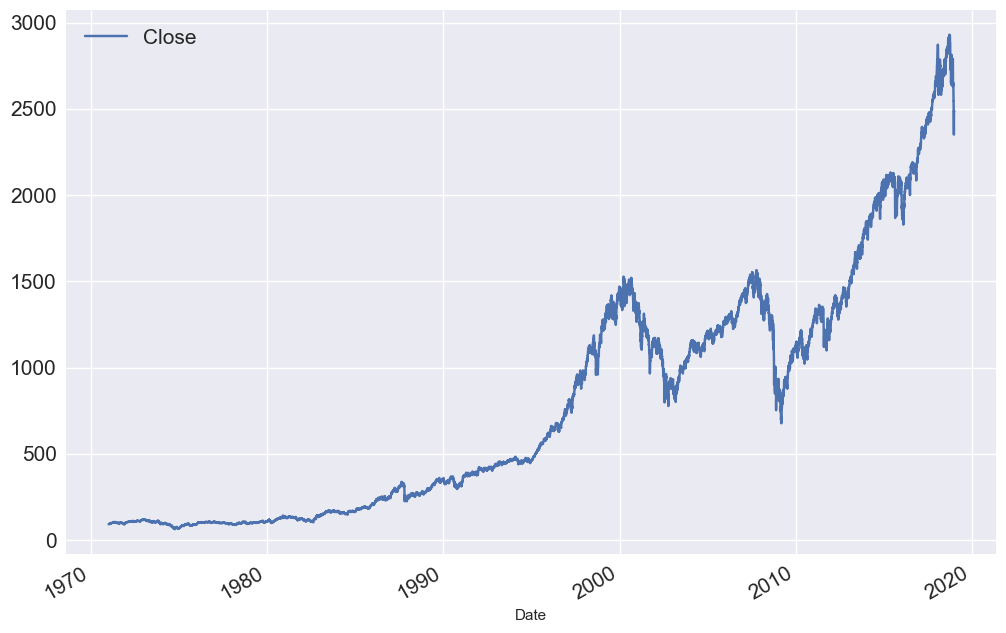

In [20]:
SP500.plot(figsize = (12,8), fontsize= 15)
plt.legend(loc = "upper left", fontsize = 15)
plt.show()

In [21]:
SP500 = SP500.loc["2008-12-31":"2018-12-31"].copy()

In [22]:
SP500.rolling(window = 10)

Rolling [window=10,center=False,axis=0,method=single]

In [23]:
type(SP500.rolling(window = 10))

pandas.core.window.rolling.Rolling

In [24]:
SP500.head(15)

,Close
Date,
2008-12-31,903.250000
2009-01-02,931.799988
2009-01-05,927.450012
2009-01-06,934.700012
2009-01-07,906.650024
2009-01-08,909.729980
2009-01-09,890.349976
2009-01-12,870.260010
2009-01-13,871.789978


In [25]:
SP500.rolling(window = 10).mean()

,Close
Date,
2008-12-31,NaN
2009-01-02,NaN
2009-01-05,NaN
2009-01-06,NaN
2009-01-07,NaN
...,...
2018-12-21,2565.915991
2018-12-24,2537.254004
2018-12-26,2520.345996


In [26]:
SP500.rolling(window = 10).mean()

,Close
Date,
2008-12-31,NaN
2009-01-02,NaN
2009-01-05,NaN
2009-01-06,NaN
2009-01-07,NaN
...,...
2018-12-21,2565.915991
2018-12-24,2537.254004
2018-12-26,2520.345996


In [27]:
SP500.rolling(window = 10, min_periods=5).mean()

,Close
Date,
2008-12-31,NaN
2009-01-02,NaN
2009-01-05,NaN
2009-01-06,NaN
2009-01-07,920.770007
...,...
2018-12-21,2565.915991
2018-12-24,2537.254004
2018-12-26,2520.345996


## Momentum Trading Strategies with SMAs

In [28]:
SP500.head()

,Close
Date,
2008-12-31,903.250000
2009-01-02,931.799988
2009-01-05,927.450012
2009-01-06,934.700012
2009-01-07,906.650024


In [29]:
SP500.tail()

,Close
Date,
2018-12-21,2416.620117
2018-12-24,2351.100098
2018-12-26,2467.699951
2018-12-27,2488.830078
2018-12-28,2485.739990


In [30]:
SP500["SMA50"] = SP500.rolling(window = 50, min_periods=50).mean()

In [31]:
SP500

,Close,SMA50
Date,,
2008-12-31,903.250000,NaN
2009-01-02,931.799988,NaN
2009-01-05,927.450012,NaN
2009-01-06,934.700012,NaN
2009-01-07,906.650024,NaN
...,...,...
2018-12-21,2416.620117,2692.420195
2018-12-24,2351.100098,2684.874795
2018-12-26,2467.699951,2678.886196


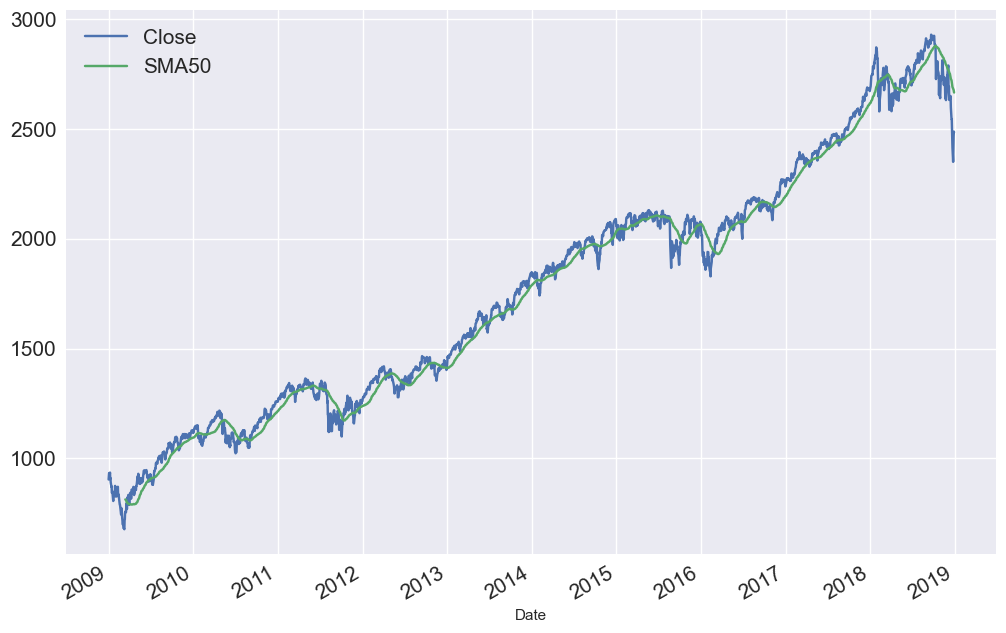

In [32]:
SP500.plot(figsize = (12, 8), fontsize = 15)
plt.legend(loc = "upper left", fontsize = 15)
plt.show()

In [33]:
SP500["SMA200"] = SP500.Close.rolling(window = 200).mean()

In [34]:
SP500.tail()

,Close,SMA50,SMA200
Date,,,
2018-12-21,2416.620117,2692.420195,2753.65980
2018-12-24,2351.100098,2684.874795,2751.48245
2018-12-26,2467.699951,2678.886196,2749.90585
2018-12-27,2488.830078,2673.646997,2748.52345
2018-12-28,2485.739990,2667.163398,2747.20475


In [35]:
SP500.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2516 entries, 2008-12-31 to 2018-12-28
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2516 non-null   float64
 1   SMA50   2467 non-null   float64
 2   SMA200  2317 non-null   float64
dtypes: float64(3)
memory usage: 78.6 KB


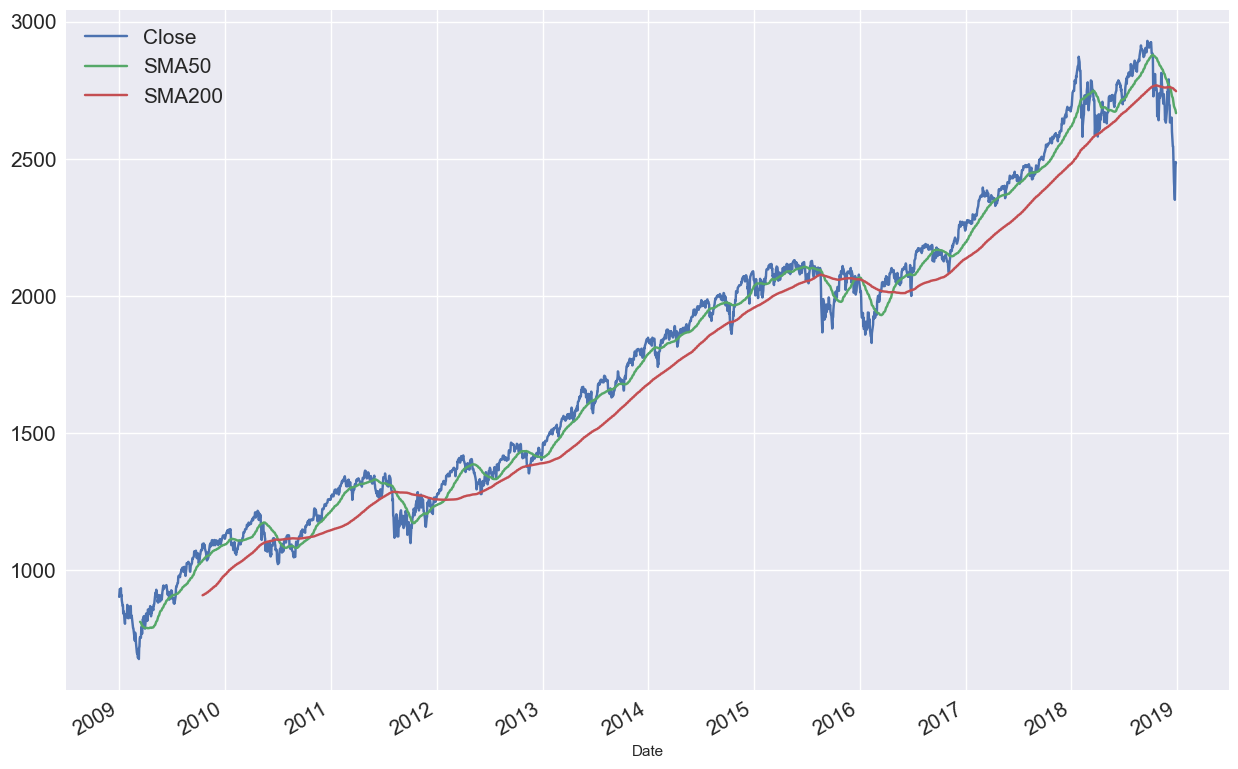

In [36]:
SP500.plot(figsize = (15,10), fontsize= 15)
plt.legend(fontsize = 15)
plt.show()

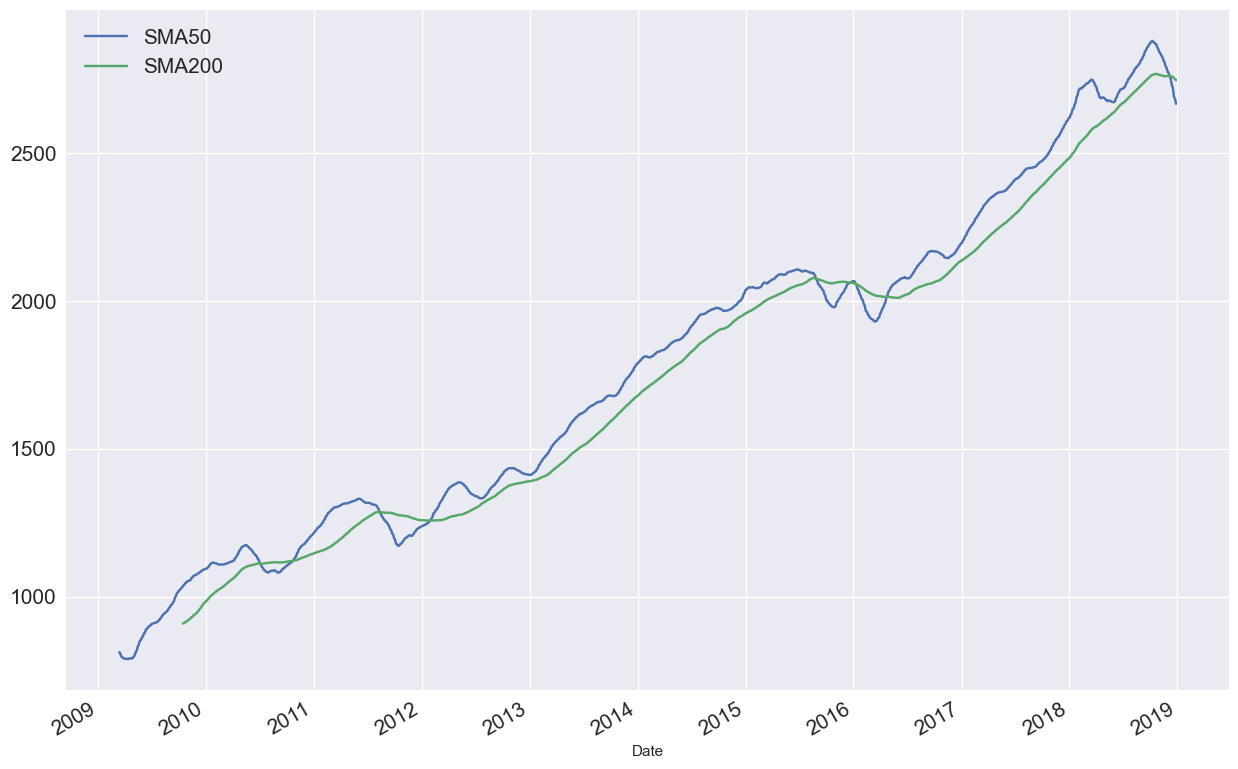

In [37]:
SP500.iloc[:,-2:].plot(figsize = (15,10), fontsize= 15)
plt.legend(fontsize = 15)
plt.show()

## Performance Reporting with rolling()

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

In [39]:
SP500 = pd.read_csv("SP500.csv", parse_dates= ["Date"], index_col = "Date", 
                    usecols= ["Date", "Close"])

In [40]:
SP500.head()

,Close
Date,
1970-12-31,92.150002
1971-01-04,91.150002
1971-01-05,91.800003
1971-01-06,92.349998
1971-01-07,92.379997


In [41]:
SP500.resample("M", kind = "period").last() # old

C:\Users\arsh\AppData\Local\Temp\ipykernel_19576\1395453378.py:1: FutureWarning: The 'kind' keyword in DataFrame.resample is deprecated and will be removed in a future version. Explicitly cast the index to the desired type instead
  SP500.resample("M", kind = "period").last() # old
C:\Users\arsh\AppData\Local\Temp\ipykernel_19576\1395453378.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  SP500.resample("M", kind = "period").last() # old


,Close
Date,
1970-12,92.150002
1971-01,95.879997
1971-02,96.750000
1971-03,100.309998
1971-04,103.949997
...,...
2018-08,2901.520020
2018-09,2913.979980
2018-10,2711.739990


In [ ]:
# old
# month_ret = SP500.resample("M", kind = "period").last().pct_change().dropna()
# month_ret

In [42]:
# new (short alternative)
month_ret = SP500.resample("ME").last().pct_change().dropna().to_period()
month_ret

,Close
Date,
1971-01,0.040477
1971-02,0.009074
1971-03,0.036796
1971-04,0.036287
1971-05,-0.041558
...,...
2018-08,0.030263
2018-09,0.004294
2018-10,-0.069403


In [43]:
month_ret.rolling(36).mean()*12

,Close
Date,
1971-01,NaN
1971-02,NaN
1971-03,NaN
1971-04,NaN
1971-05,NaN
...,...
2018-08,0.133653
2018-09,0.143899
2018-10,0.093103


In [44]:
month_ret["Return"] = month_ret.rolling(36).mean()*12

In [45]:
month_ret.Close.rolling(36).std()*np.sqrt(12)

Date
1971-01         NaN
1971-02         NaN
1971-03         NaN
1971-04         NaN
1971-05         NaN
             ...   
2018-08    0.094305
2018-09    0.091740
2018-10    0.093480
2018-11    0.093556
2018-12    0.111514
Freq: M, Name: Close, Length: 576, dtype: float64

In [46]:
month_ret["Risk"] = month_ret.Close.rolling(36).std()*np.sqrt(12)

In [47]:
month_ret.dropna(inplace= True)

In [48]:
month_ret.head()

,Close,Return,Risk
Date,,,
1973-12,0.016569,0.026493,0.123219
1974-01,-0.010046,0.009652,0.121276
1974-02,-0.003624,0.005419,0.121201
1974-03,-0.023280,-0.014606,0.119981
1974-04,-0.039051,-0.039719,0.119791


In [49]:
month_ret.tail()

,Close,Return,Risk
Date,,,
2018-08,0.030263,0.133653,0.094305
2018-09,0.004294,0.143899,0.091740
2018-10,-0.069403,0.093103,0.093480
2018-11,0.017859,0.098888,0.093556
2018-12,-0.099425,0.071590,0.111514


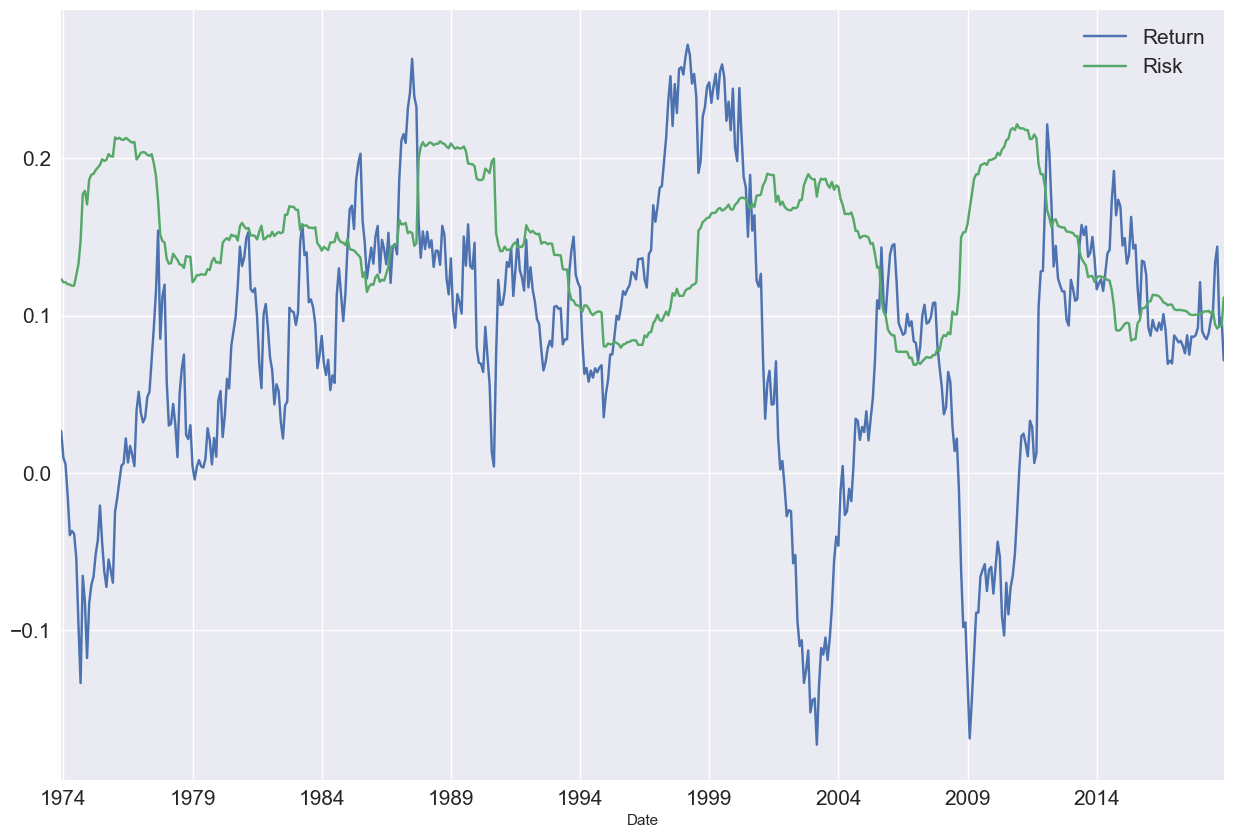

In [50]:
month_ret.iloc[:,-2:].plot(figsize = (15,10), fontsize= 15)
plt.legend(fontsize = 15)
plt.show()

In [51]:
month_ret.iloc[:,-2:].corr()

,Return,Risk
Return,1.000000,-0.327747
Risk,-0.327747,1.000000


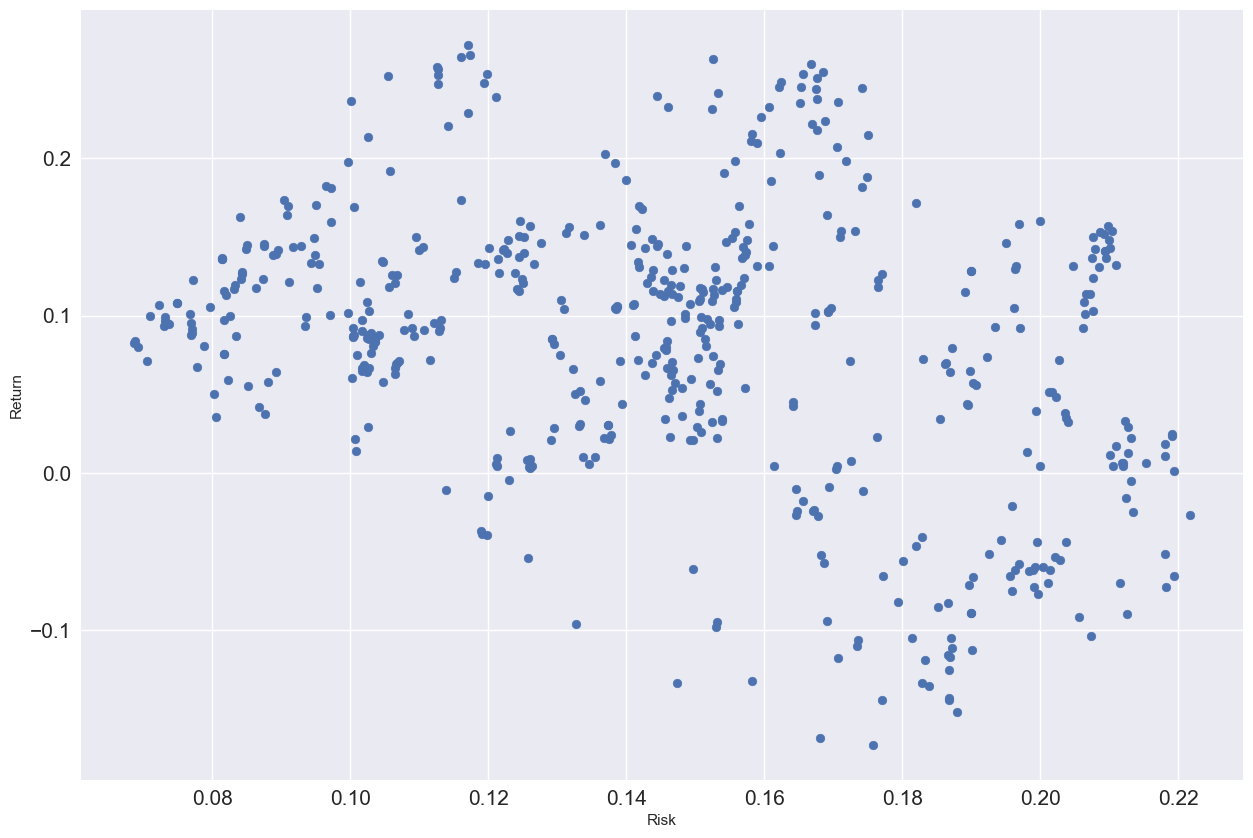

In [52]:
month_ret.iloc[:,-2:].plot(kind = "scatter", x = "Risk", y = "Return", figsize = (15,10), fontsize= 15, s = 40)
plt.show()

## Performance and Investment Periods / Time Diversification

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

In [54]:
SP500 = pd.read_csv("SP500.csv", parse_dates= ["Date"], index_col = "Date",
                    usecols = ["Date", "Close"])

In [55]:
SP500.head()

,Close
Date,
1970-12-31,92.150002
1971-01-04,91.150002
1971-01-05,91.800003
1971-01-06,92.349998
1971-01-07,92.379997


In [56]:
SP500.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12107 entries, 1970-12-31 to 2018-12-28
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   12107 non-null  float64
dtypes: float64(1)
memory usage: 189.2 KB


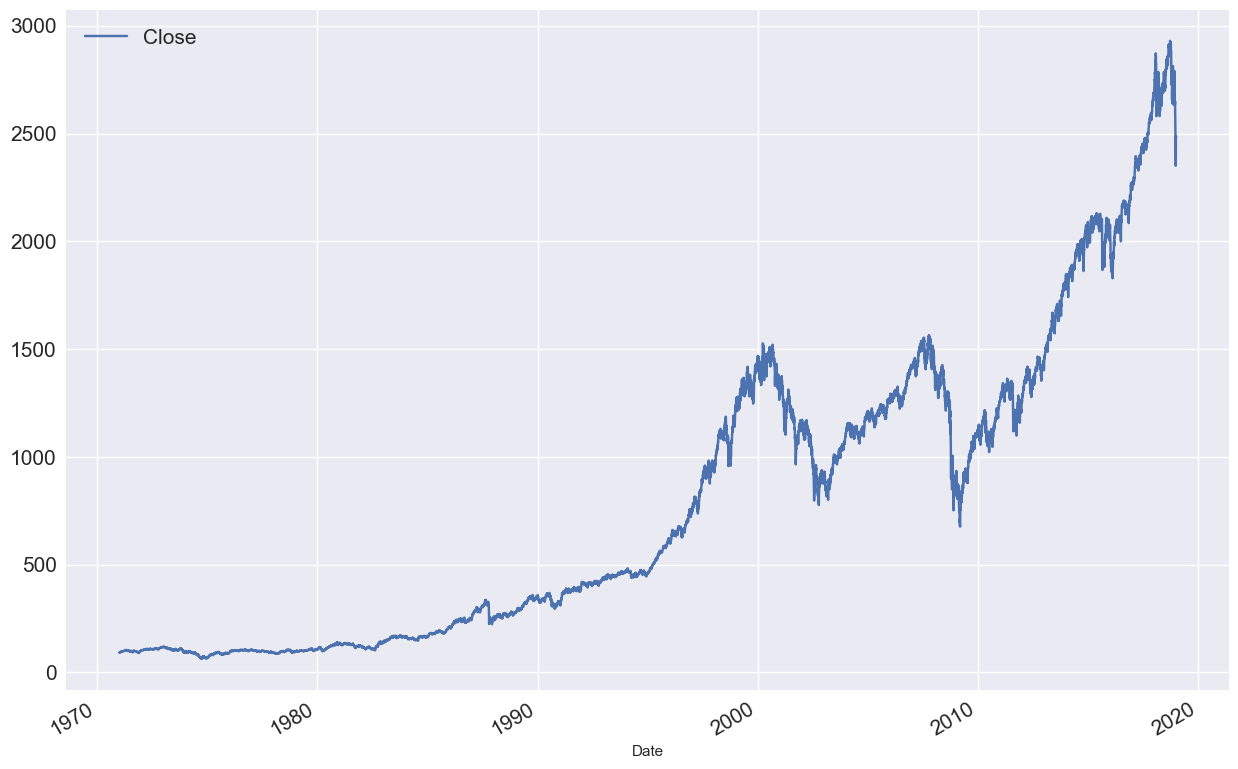

In [57]:
SP500.plot(figsize = (15,10), fontsize= 15)
plt.legend(fontsize = 15)
plt.show()

In [ ]:
# month_ret = SP500.resample("M", kind = "period").last().pct_change().dropna() # old

In [58]:
# new
month_ret = SP500.resample("ME").last().pct_change().dropna().to_period()
month_ret

,Close
Date,
1971-01,0.040477
1971-02,0.009074
1971-03,0.036796
1971-04,0.036287
1971-05,-0.041558
...,...
2018-08,0.030263
2018-09,0.004294
2018-10,-0.069403


In [59]:
month_ret.tail()

,Close
Date,
2018-08,0.030263
2018-09,0.004294
2018-10,-0.069403
2018-11,0.017859
2018-12,-0.099425


In [60]:
month_ret.columns = ["m_returns"]

In [61]:
month_ret.rolling(3 * 12).mean()*12

,m_returns
Date,
1971-01,NaN
1971-02,NaN
1971-03,NaN
1971-04,NaN
1971-05,NaN
...,...
2018-08,0.133653
2018-09,0.143899
2018-10,0.093103


In [62]:
for years in [1, 3, 5, 10, 20]:
    month_ret["{}Y".format(years)] = month_ret.m_returns.rolling(years*12).mean()*12

In [63]:
month_ret.tail()

,m_returns,1Y,3Y,5Y,10Y,20Y
Date,,,,,,
2018-08,0.030263,0.165207,0.133653,0.119980,0.092904,0.066120
2018-09,0.004294,0.150198,0.143899,0.114889,0.102412,0.063215
2018-10,-0.069403,0.058606,0.093103,0.092089,0.112415,0.055730
2018-11,0.017859,0.048383,0.098888,0.090051,0.121685,0.053667
2018-12,-0.099425,-0.060874,0.071590,0.065453,0.110961,0.045877


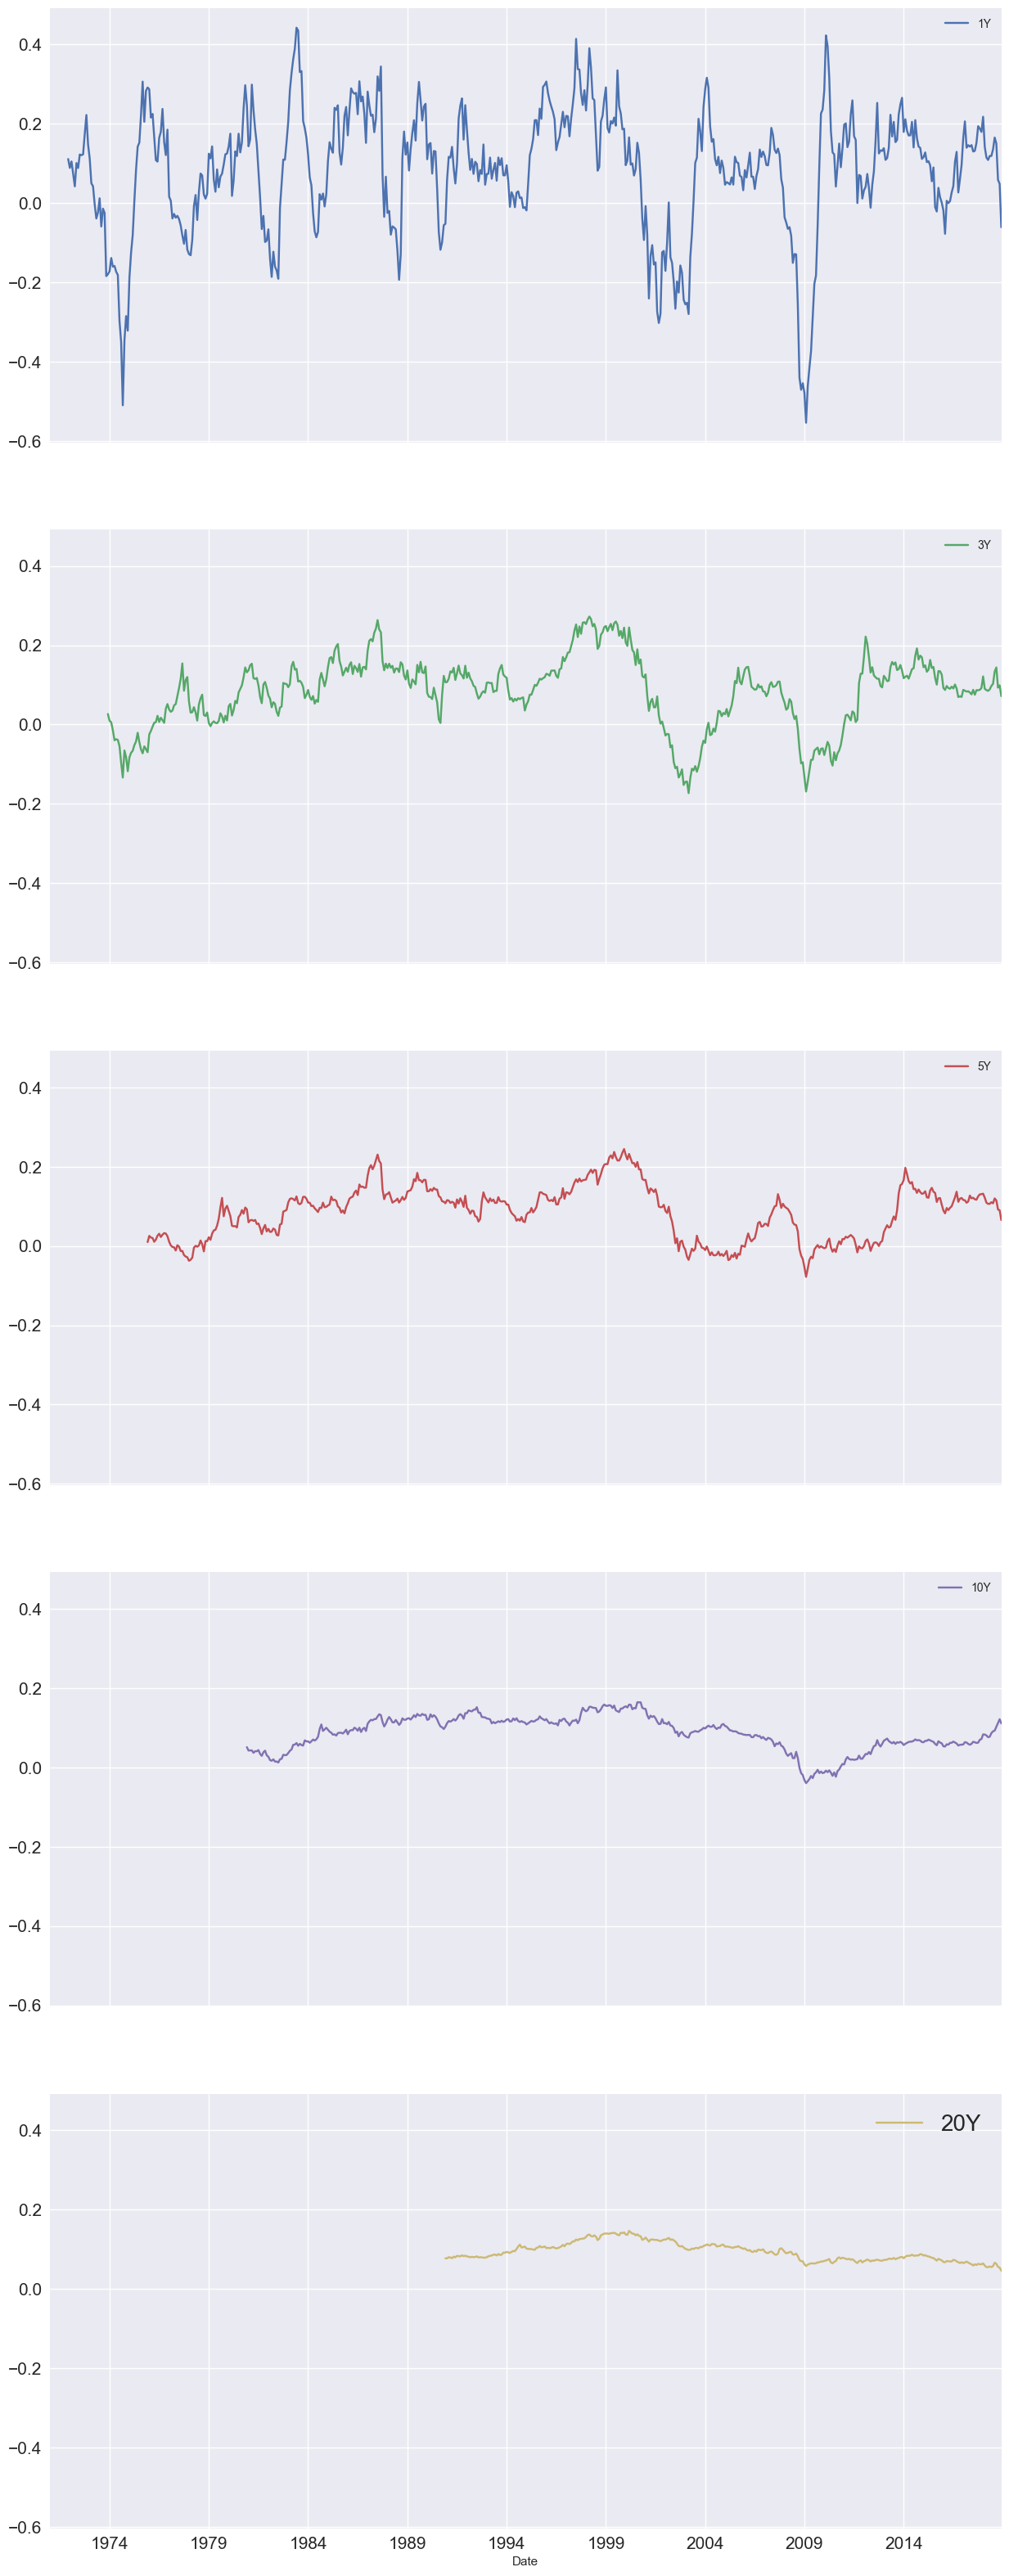

In [64]:
month_ret.iloc[:,-5:].plot(figsize = (15,40), subplots =True, fontsize= 15, sharey = True)
plt.legend(fontsize = 20)
plt.show()

## Simple Returns vs. Log Returns

In [65]:
import pandas as pd
import numpy as np

In [66]:
df = pd.DataFrame(index = [2016, 2017, 2018], data = [100, 50, 95], columns = ["Price"])

In [67]:
df

,Price
2016,100
2017,50
2018,95


In [68]:
simple_returns = df.pct_change().dropna()
simple_returns

,Price
2017,-0.5
2018,0.9


In [69]:
simple_returns.mean()

Price    0.2
dtype: float64

In [70]:
100 * 1.2 * 1.2

144.0

In [71]:
df

,Price
2016,100
2017,50
2018,95


In [72]:
np.log(df / df.shift(1))

,Price
2016,NaN
2017,-0.693147
2018,0.641854


In [73]:
log_returns = np.log(df / df.shift(1)).dropna()

In [74]:
log_returns

,Price
2017,-0.693147
2018,0.641854


In [75]:
log_returns.mean()

Price   -0.025647
dtype: float64

In [76]:
100 * np.exp(2 * log_returns.mean())

Price    95.0
dtype: float64

## The S&P 500 Return Triangle

In [77]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

In [78]:
SP500 = pd.read_csv("SP500.csv", parse_dates= ["Date"], index_col= "Date", 
                    usecols = ["Date", "Close"])

In [79]:
SP500.head()

,Close
Date,
1970-12-31,92.150002
1971-01-04,91.150002
1971-01-05,91.800003
1971-01-06,92.349998
1971-01-07,92.379997


In [80]:
SP500 = SP500.loc["1988-12-30":"2018-12-31"].copy()

In [81]:
SP500.head()

,Close
Date,
1988-12-30,277.720001
1989-01-03,275.309998
1989-01-04,279.429993
1989-01-05,280.010010
1989-01-06,280.670013


In [ ]:
# old
# annual = SP500.resample("A", kind = "period").last()
# annual

In [82]:
# new
annual = SP500.resample("YE").last().to_period()
annual

,Close
Date,
1988,277.720001
1989,353.399994
1990,330.220001
1991,417.089996
1992,435.709991
1993,466.450012
1994,459.269989
1995,615.929993
1996,740.739990


In [83]:
annual["Return"] = np.log(annual.Close / annual.Close.shift())

In [84]:

annual.dropna(inplace = True)

In [85]:
annual

,Close,Return
Date,,
1989,353.399994,0.240987
1990,330.220001,-0.067841
1991,417.089996,0.233543
1992,435.709991,0.043675
1993,466.450012,0.068174
1994,459.269989,-0.015513
1995,615.929993,0.293495
1996,740.739990,0.184516
1997,970.429993,0.270090


In [86]:
years = annual.index.size
years

30

In [87]:
windows = [year for year in range(30, 0, -1)]
windows

[30,
 29,
 28,
 27,
 26,
 25,
 24,
 23,
 22,
 21,
 20,
 19,
 18,
 17,
 16,
 15,
 14,
 13,
 12,
 11,
 10,
 9,
 8,
 7,
 6,
 5,
 4,
 3,
 2,
 1]

In [88]:
for year in windows:
    annual["{}Y".format(year)] = annual.Return.rolling(year).mean()

In [89]:
annual

,Close,Return,30Y,29Y,28Y,27Y,26Y,25Y,24Y,23Y,...,10Y,9Y,8Y,7Y,6Y,5Y,4Y,3Y,2Y,1Y
Date,,,,,,,,,,,,,,,,,,,,,
1989,353.399994,0.240987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.240987
1990,330.220001,-0.067841,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.086573,-0.067841
1991,417.089996,0.233543,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.135563,0.082851,0.233543
1992,435.709991,0.043675,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.112591,0.069792,0.138609,0.043675
1993,466.450012,0.068174,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.103707,0.069388,0.115131,0.055924,0.068174
1994,459.269989,-0.015513,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.083837,0.052408,0.082470,0.032112,0.026331,-0.015513
1995,615.929993,0.293495,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.113789,0.092589,0.124675,0.097458,0.115385,0.138991,0.293495
1996,740.739990,0.184516,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.122630,0.105721,0.134648,0.114870,0.132668,0.154166,0.239006,0.184516
1997,970.429993,0.270090,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.139014,0.126267,0.153997,0.140740,0.160152,0.183147,0.249367,0.227303,0.270090


In [90]:
triangle = annual.drop(columns = ["Close", "Return"])

In [91]:
triangle

,30Y,29Y,28Y,27Y,26Y,25Y,24Y,23Y,22Y,21Y,...,10Y,9Y,8Y,7Y,6Y,5Y,4Y,3Y,2Y,1Y
Date,,,,,,,,,,,,,,,,,,,,,
1989,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.240987
1990,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.086573,-0.067841
1991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.135563,0.082851,0.233543
1992,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.112591,0.069792,0.138609,0.043675
1993,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.103707,0.069388,0.115131,0.055924,0.068174
1994,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.083837,0.052408,0.082470,0.032112,0.026331,-0.015513
1995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,0.113789,0.092589,0.124675,0.097458,0.115385,0.138991,0.293495
1996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.122630,0.105721,0.134648,0.114870,0.132668,0.154166,0.239006,0.184516
1997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.139014,0.126267,0.153997,0.140740,0.160152,0.183147,0.249367,0.227303,0.270090


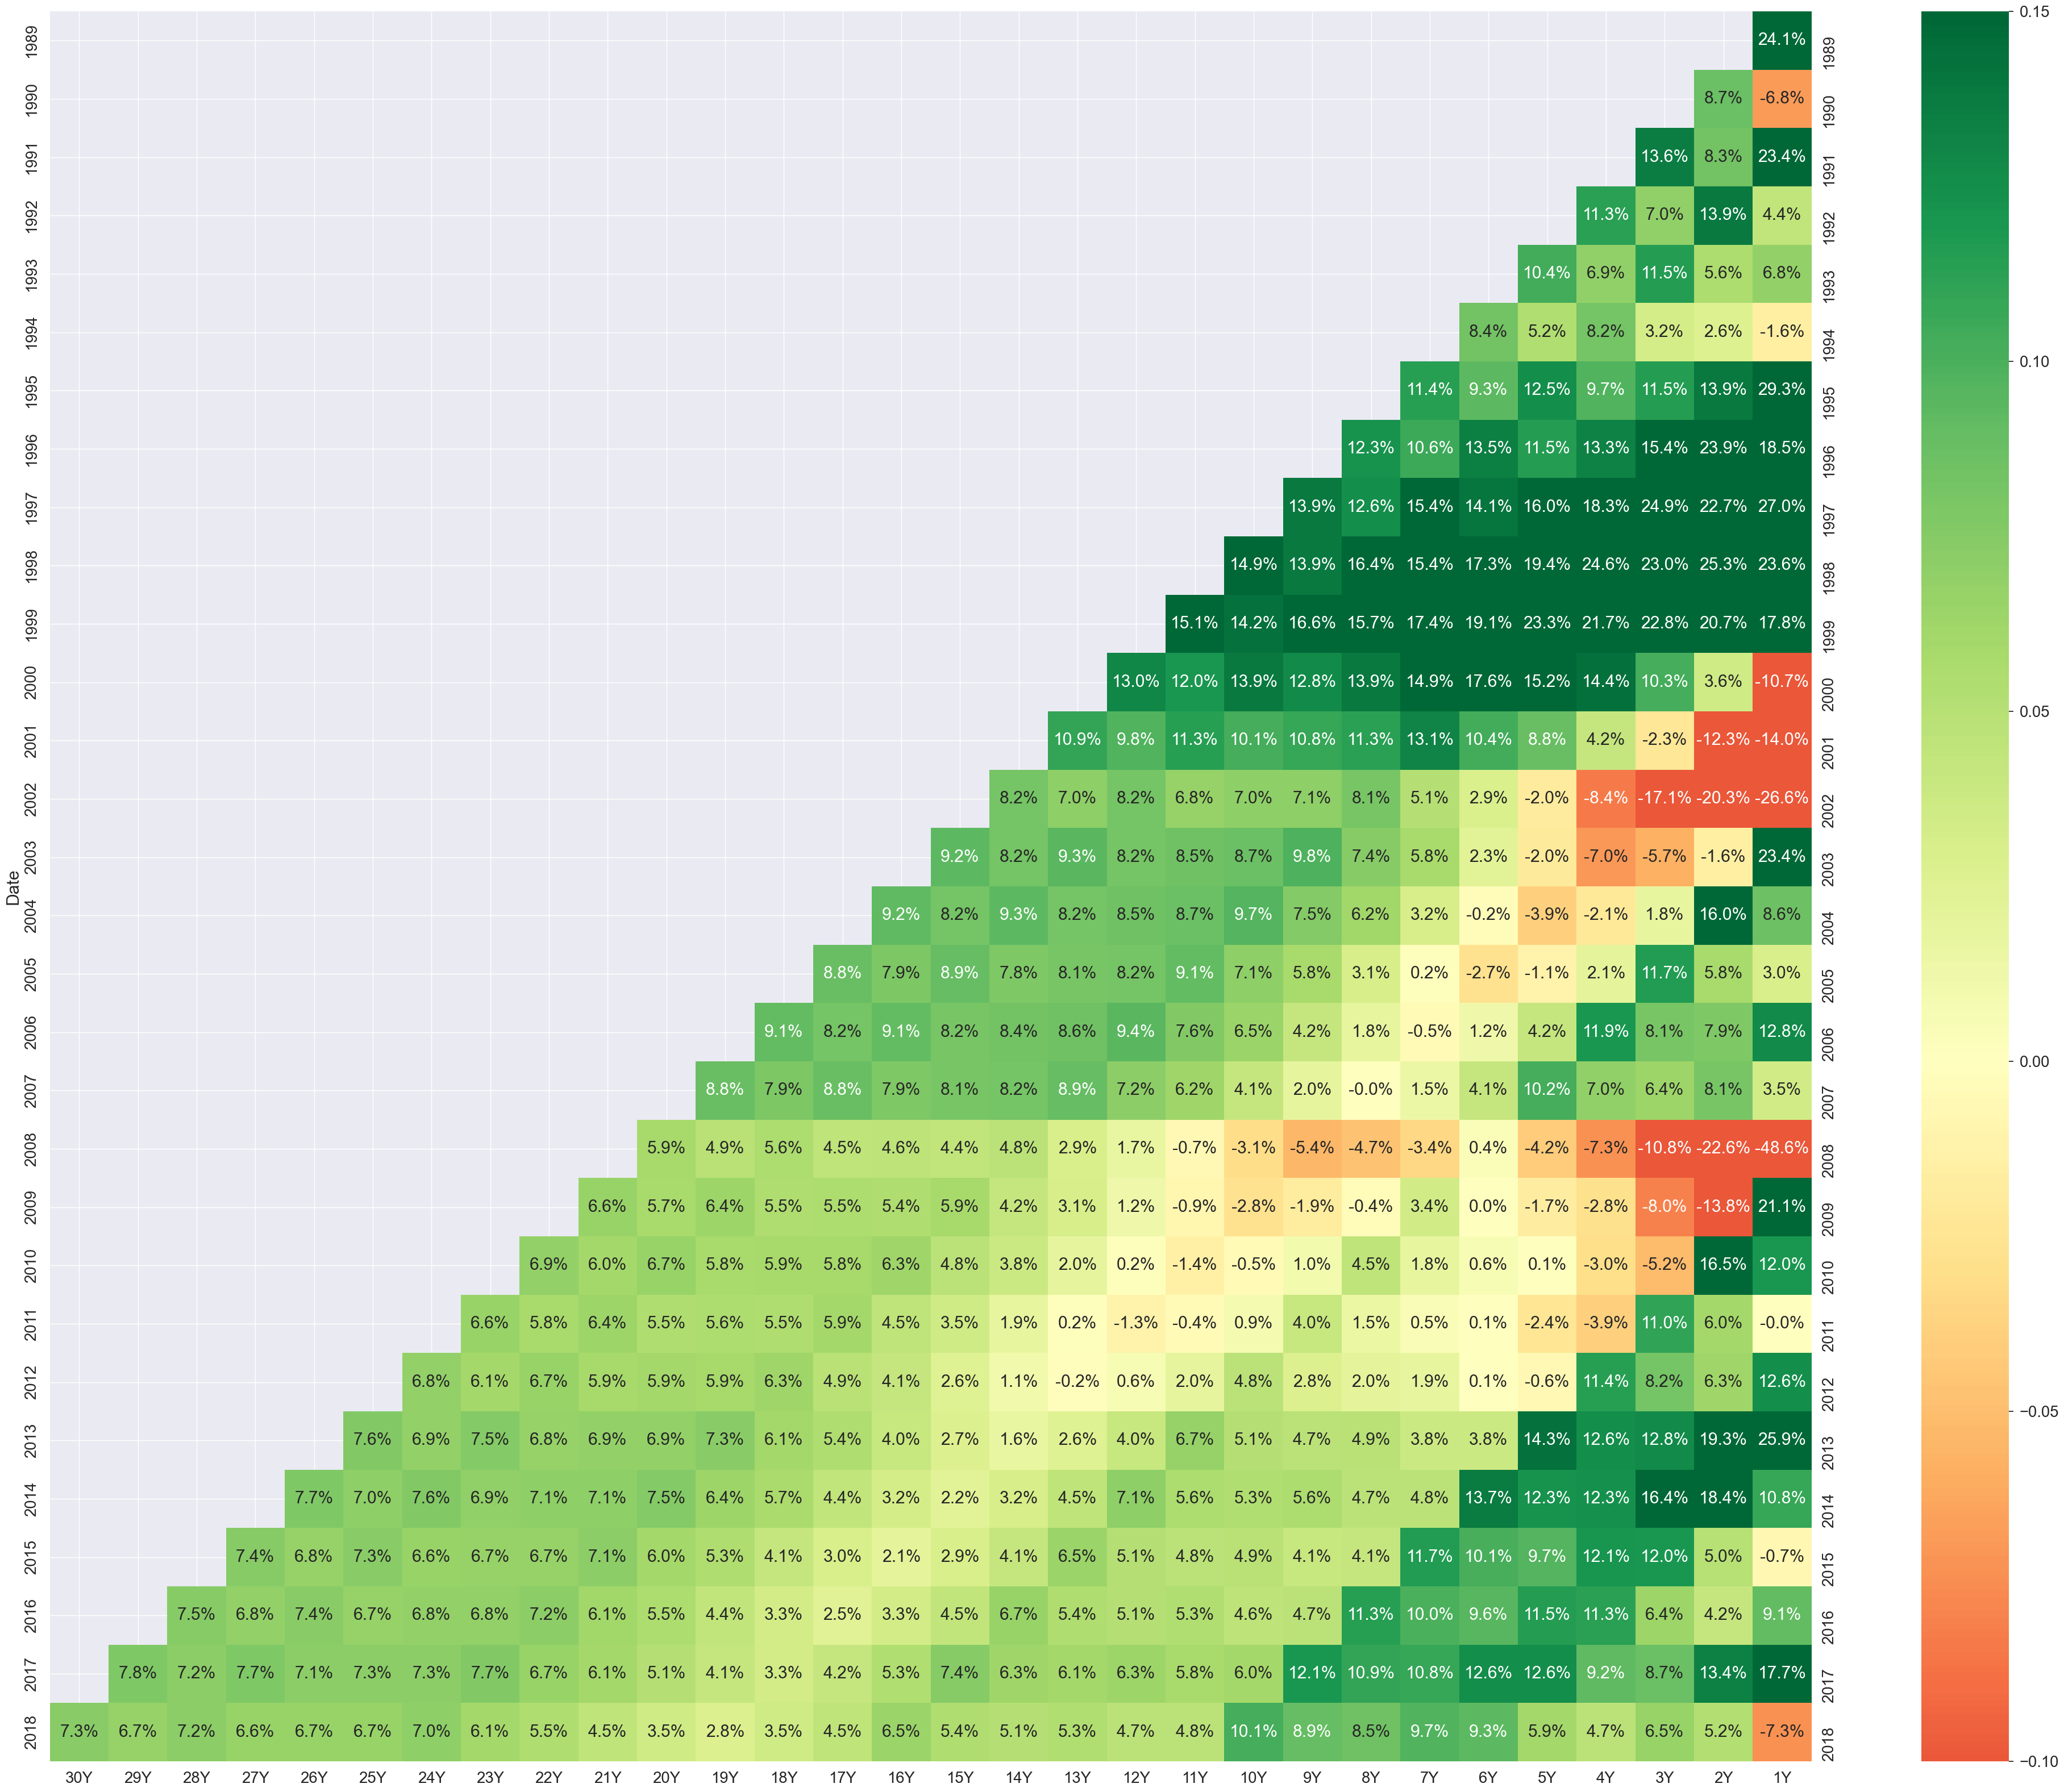

In [92]:
plt.figure(figsize=(50,40))
sns.set(font_scale=1.8)
sns.heatmap(triangle, annot = True, fmt = ".1%", cmap = "RdYlGn", 
            vmin = -0.10, vmax = 0.15, center = 0)
plt.tick_params(axis = "y", labelright =True)
plt.show()

## The S&P 500 Dollar Triangle

In [93]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")
pd.options.display.float_format = '{:.0f}'.format

In [94]:
SP500 = pd.read_csv("SP500.csv", parse_dates= ["Date"], index_col= "Date", 
                    usecols = ["Date", "Close"])

In [95]:
SP500.head()

,Close
Date,
1970-12-31,92
1971-01-04,91
1971-01-05,92
1971-01-06,92
1971-01-07,92


In [96]:
SP500 = SP500.loc["1988-12-30":"2018-12-31"].copy()

In [97]:
SP500.head()

,Close
Date,
1988-12-30,278
1989-01-03,275
1989-01-04,279
1989-01-05,280
1989-01-06,281


In [ ]:
# old
# annual = SP500.resample("A", kind = "period").last()
# annual

In [98]:
# new
annual = SP500.resample("YE").last().to_period()
annual

,Close
Date,
1988,278
1989,353
1990,330
1991,417
1992,436
1993,466
1994,459
1995,616
1996,741


In [99]:
annual["Return"] = np.log(annual.Close / annual.Close.shift())

In [100]:
annual.dropna(inplace = True)

In [101]:
annual

,Close,Return
Date,,
1989,353,0
1990,330,-0
1991,417,0
1992,436,0
1993,466,0
1994,459,-0
1995,616,0
1996,741,0
1997,970,0


In [102]:
years = annual.index.size
years

30

In [103]:
windows = [year for year in range(30, 0, -1)]
windows

[30,
 29,
 28,
 27,
 26,
 25,
 24,
 23,
 22,
 21,
 20,
 19,
 18,
 17,
 16,
 15,
 14,
 13,
 12,
 11,
 10,
 9,
 8,
 7,
 6,
 5,
 4,
 3,
 2,
 1]

In [ ]:
#for year in windows:
    #annual["{}Y".format(year)] = annual.Return.rolling(year).mean()

In [104]:
for year in windows:
    annual["{}Y".format(year)] = np.exp(year * annual.Return.rolling(year).mean()) * 100

In [105]:
annual

,Close,Return,30Y,29Y,28Y,27Y,26Y,25Y,24Y,23Y,...,10Y,9Y,8Y,7Y,6Y,5Y,4Y,3Y,2Y,1Y
Date,,,,,,,,,,,,,,,,,,,,,
1989,353,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,127
1990,330,-0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,119,93
1991,417,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,150,118,126
1992,436,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,157,123,132,104
1993,466,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,168,132,141,112,107
1994,459,-0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,165,130,139,110,105,98
1995,616,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,222,174,187,148,141,132,134
1996,741,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,267,210,224,178,170,159,161,120
1997,970,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,349,275,294,233,223,208,211,158,131


In [106]:
triangle = annual.drop(columns = ["Close", "Return"])

In [107]:
triangle

,30Y,29Y,28Y,27Y,26Y,25Y,24Y,23Y,22Y,21Y,...,10Y,9Y,8Y,7Y,6Y,5Y,4Y,3Y,2Y,1Y
Date,,,,,,,,,,,,,,,,,,,,,
1989,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,127
1990,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,119,93
1991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,150,118,126
1992,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,157,123,132,104
1993,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,168,132,141,112,107
1994,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,165,130,139,110,105,98
1995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,222,174,187,148,141,132,134
1996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,267,210,224,178,170,159,161,120
1997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,349,275,294,233,223,208,211,158,131


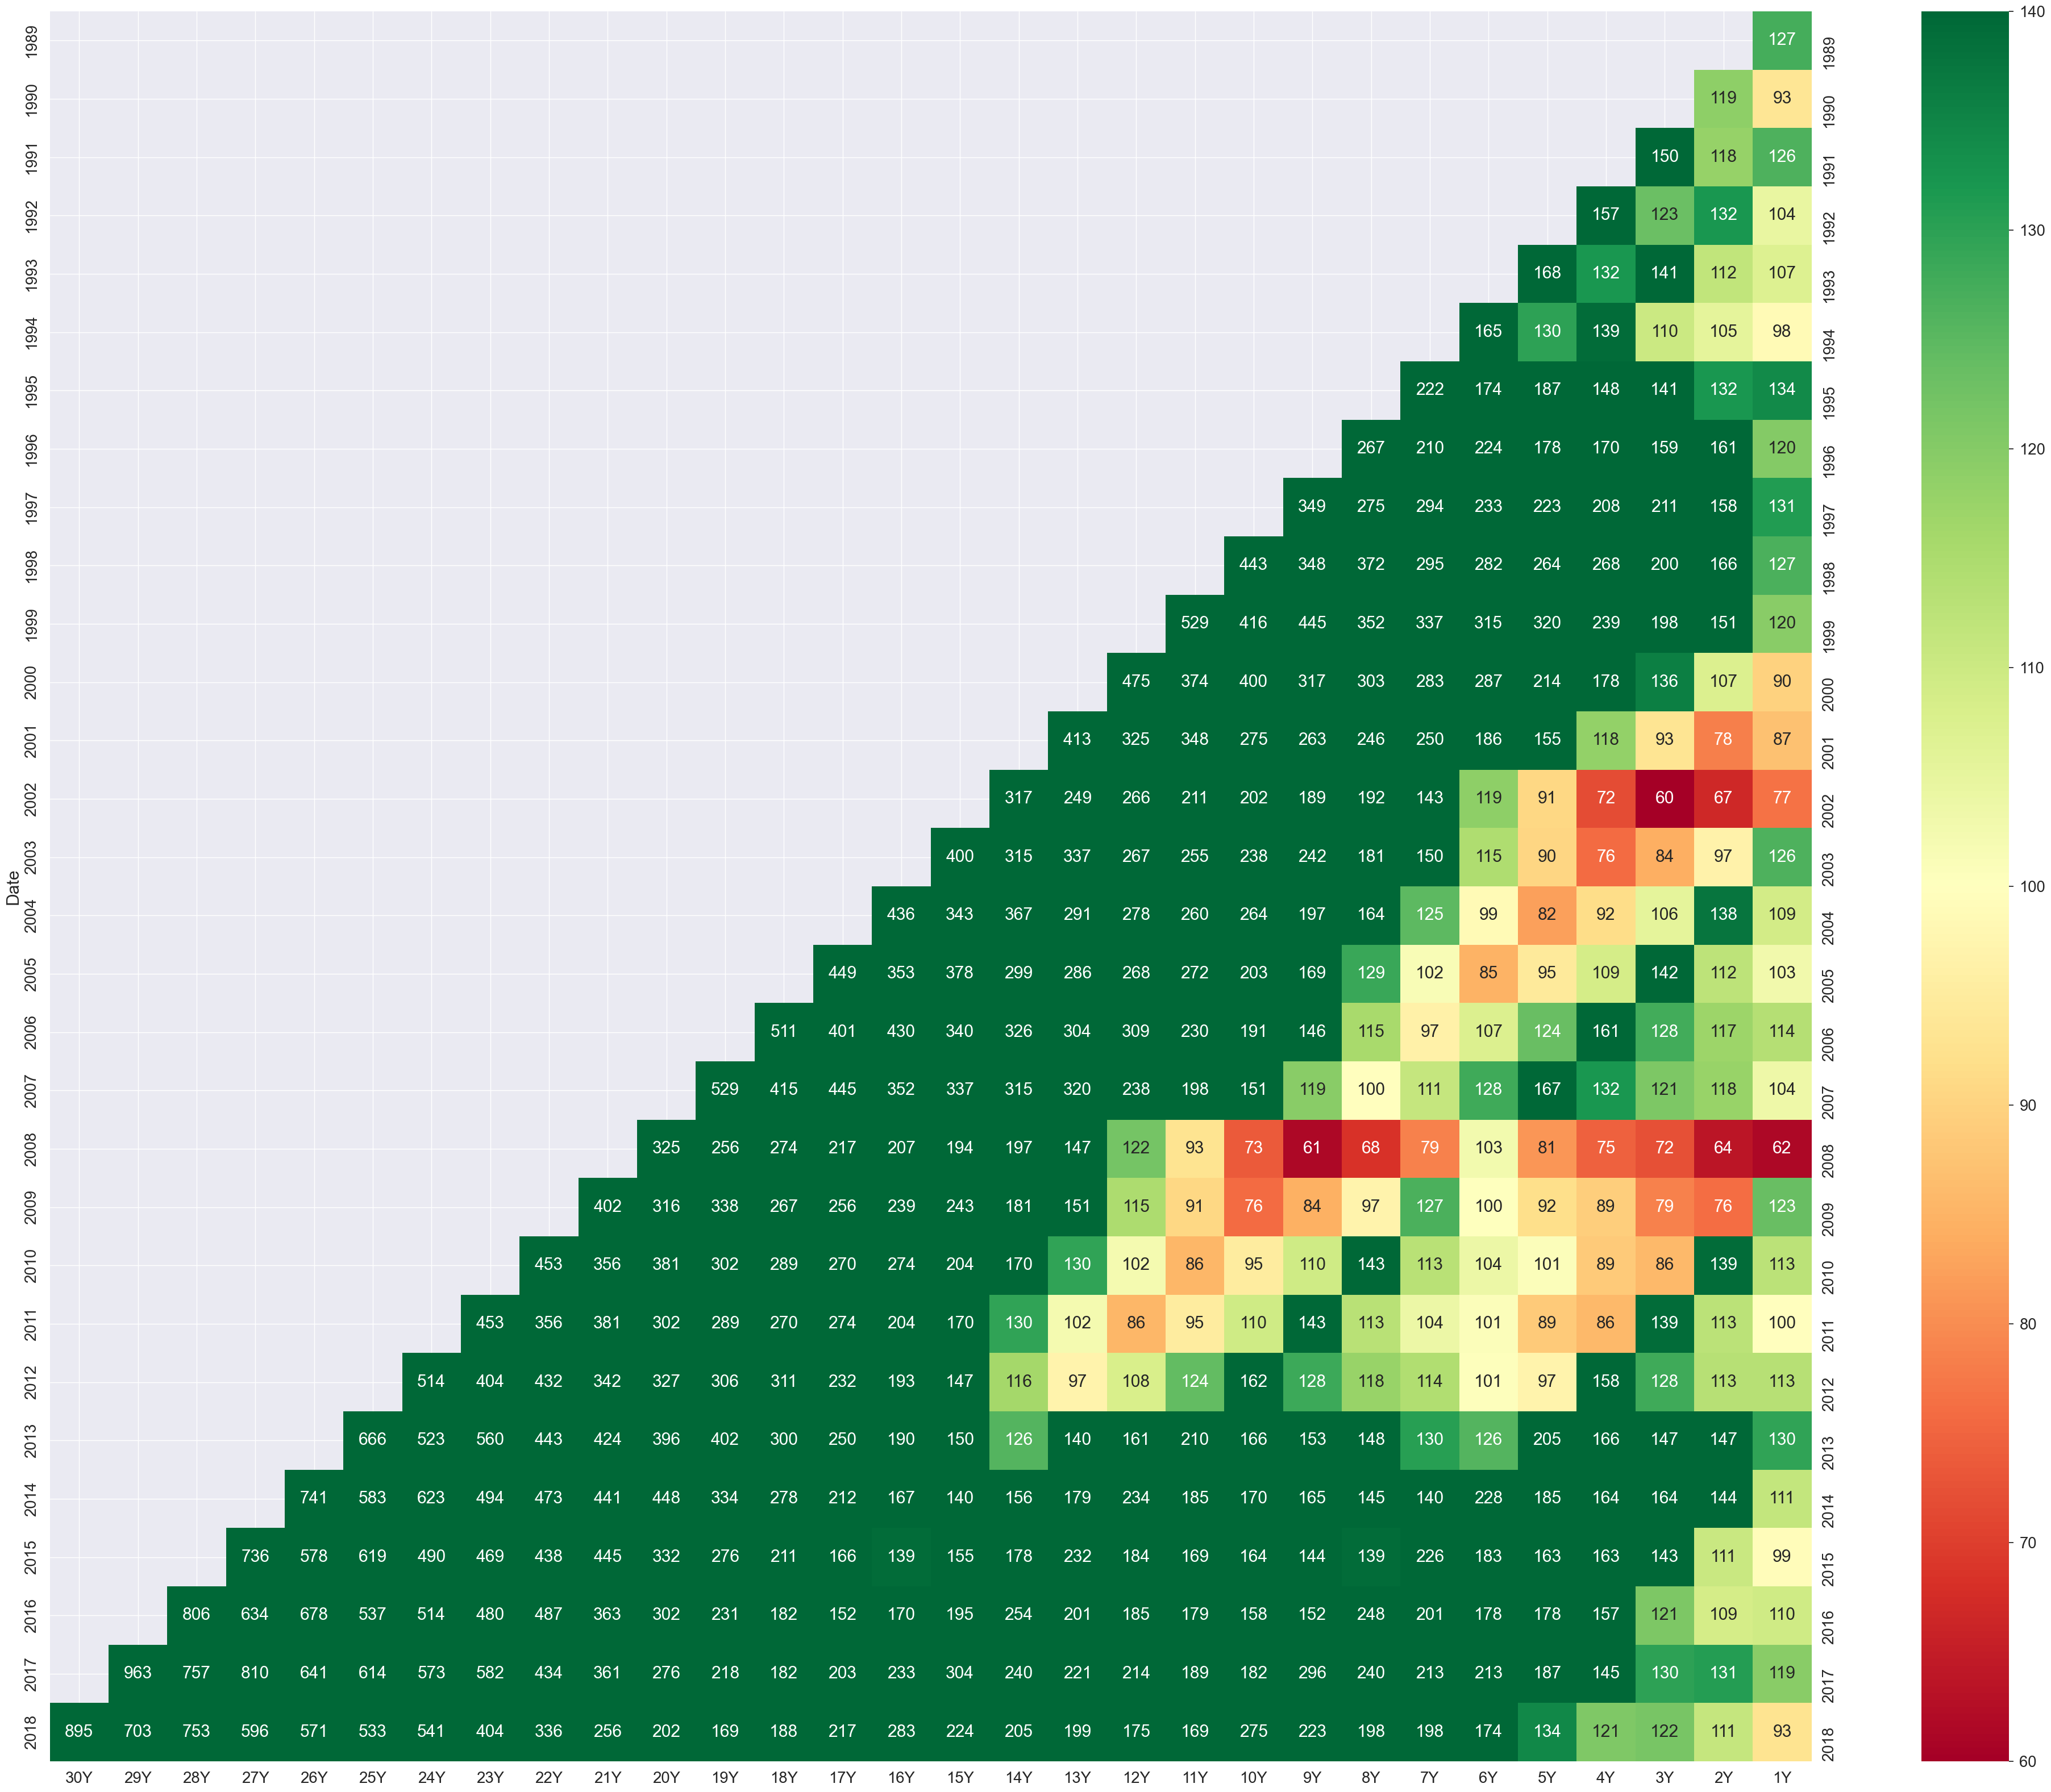

In [108]:
plt.figure(figsize=(50,40))
sns.set(font_scale=1.8)
sns.heatmap(triangle, annot = True, fmt = ".0f",  cmap = "RdYlGn", 
            vmin =60, vmax = 140, center = 100)
plt.tick_params(axis = "y", labelright =True)
plt.show()

## The S&P 500 Return Radar

In [109]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

In [111]:
SP500 = pd.read_csv("SP500.csv", parse_dates= ["Date"], index_col= "Date", 
                    usecols = ["Date", "Close"])

In [112]:
SP500.head()

,Close
Date,
1970-12-31,92
1971-01-04,91
1971-01-05,92
1971-01-06,92
1971-01-07,92


In [113]:
SP500 = SP500.loc["1988-12-30":"2018-12-31"].copy()

In [114]:
SP500.head()

,Close
Date,
1988-12-30,278
1989-01-03,275
1989-01-04,279
1989-01-05,280
1989-01-06,281


In [ ]:
# old
# weekly = SP500.resample("W", kind = "period").last()
# weekly

In [115]:
# new
weekly = SP500.resample("W").last().to_period()
weekly

,Close
Date,
1988-12-26/1989-01-01,278
1989-01-02/1989-01-08,281
1989-01-09/1989-01-15,284
1989-01-16/1989-01-22,287
1989-01-23/1989-01-29,294
...,...
2018-11-26/2018-12-02,2760
2018-12-03/2018-12-09,2633
2018-12-10/2018-12-16,2600


In [116]:
weekly["Return"] = np.log(weekly.Close / weekly.Close.shift())*52

In [117]:
weekly.dropna(inplace = True)

In [118]:
weekly

,Close,Return
Date,,
1989-01-02/1989-01-08,281,1
1989-01-09/1989-01-15,284,1
1989-01-16/1989-01-22,287,1
1989-01-23/1989-01-29,294,1
1989-01-30/1989-02-05,297,1
...,...,...
2018-11-26/2018-12-02,2760,2
2018-12-03/2018-12-09,2633,-2
2018-12-10/2018-12-16,2600,-1


In [119]:
weeks = weekly.index.size
weeks

1565

In [120]:
windows = [week for week in range(weeks, 0, -1)]
windows

[1565,
 1564,
 1563,
 1562,
 1561,
 1560,
 1559,
 1558,
 1557,
 1556,
 1555,
 1554,
 1553,
 1552,
 1551,
 1550,
 1549,
 1548,
 1547,
 1546,
 1545,
 1544,
 1543,
 1542,
 1541,
 1540,
 1539,
 1538,
 1537,
 1536,
 1535,
 1534,
 1533,
 1532,
 1531,
 1530,
 1529,
 1528,
 1527,
 1526,
 1525,
 1524,
 1523,
 1522,
 1521,
 1520,
 1519,
 1518,
 1517,
 1516,
 1515,
 1514,
 1513,
 1512,
 1511,
 1510,
 1509,
 1508,
 1507,
 1506,
 1505,
 1504,
 1503,
 1502,
 1501,
 1500,
 1499,
 1498,
 1497,
 1496,
 1495,
 1494,
 1493,
 1492,
 1491,
 1490,
 1489,
 1488,
 1487,
 1486,
 1485,
 1484,
 1483,
 1482,
 1481,
 1480,
 1479,
 1478,
 1477,
 1476,
 1475,
 1474,
 1473,
 1472,
 1471,
 1470,
 1469,
 1468,
 1467,
 1466,
 1465,
 1464,
 1463,
 1462,
 1461,
 1460,
 1459,
 1458,
 1457,
 1456,
 1455,
 1454,
 1453,
 1452,
 1451,
 1450,
 1449,
 1448,
 1447,
 1446,
 1445,
 1444,
 1443,
 1442,
 1441,
 1440,
 1439,
 1438,
 1437,
 1436,
 1435,
 1434,
 1433,
 1432,
 1431,
 1430,
 1429,
 1428,
 1427,
 1426,
 1425,
 1424,
 1423,

In [121]:
for week in windows:
    weekly["{}W".format(week)] = weekly.Return.rolling(week).mean()

C:\Users\arsh\AppData\Local\Temp\ipykernel_19576\167997240.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  weekly["{}W".format(week)] = weekly.Return.rolling(week).mean()
C:\Users\arsh\AppData\Local\Temp\ipykernel_19576\167997240.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  weekly["{}W".format(week)] = weekly.Return.rolling(week).mean()
C:\Users\arsh\AppData\Local\Temp\ipykernel_19576\167997240.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, w

In [122]:
weekly

,Close,Return,1565W,1564W,1563W,1562W,1561W,1560W,1559W,1558W,...,10W,9W,8W,7W,6W,5W,4W,3W,2W,1W
Date,,,,,,,,,,,,,,,,,,,,,
1989-01-02/1989-01-08,281,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1989-01-09/1989-01-15,284,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
1989-01-16/1989-01-22,287,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1
1989-01-23/1989-01-29,294,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1,1
1989-01-30/1989-02-05,297,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-11-26/2018-12-02,2760,2,NaN,NaN,NaN,NaN,0,0,0,0,...,-0,-0,-0,-0,-0,0,0,-0,0,2
2018-12-03/2018-12-09,2633,-2,NaN,NaN,NaN,0,0,0,0,0,...,-1,-1,-0,-0,-0,-0,-1,-1,0,-2
2018-12-10/2018-12-16,2600,-1,NaN,NaN,0,0,0,0,0,0,...,-1,-0,-0,-0,-0,-1,-1,-0,-2,-1


In [123]:
triangle = weekly.drop(columns = ["Close", "Return"])

In [124]:
triangle

,1565W,1564W,1563W,1562W,1561W,1560W,1559W,1558W,1557W,1556W,...,10W,9W,8W,7W,6W,5W,4W,3W,2W,1W
Date,,,,,,,,,,,,,,,,,,,,,
1989-01-02/1989-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1989-01-09/1989-01-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1
1989-01-16/1989-01-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1
1989-01-23/1989-01-29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1,1,1,1
1989-01-30/1989-02-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-11-26/2018-12-02,NaN,NaN,NaN,NaN,0,0,0,0,0,0,...,-0,-0,-0,-0,-0,0,0,-0,0,2
2018-12-03/2018-12-09,NaN,NaN,NaN,0,0,0,0,0,0,0,...,-1,-1,-0,-0,-0,-0,-1,-1,0,-2
2018-12-10/2018-12-16,NaN,NaN,0,0,0,0,0,0,0,0,...,-1,-0,-0,-0,-0,-1,-1,-0,-2,-1


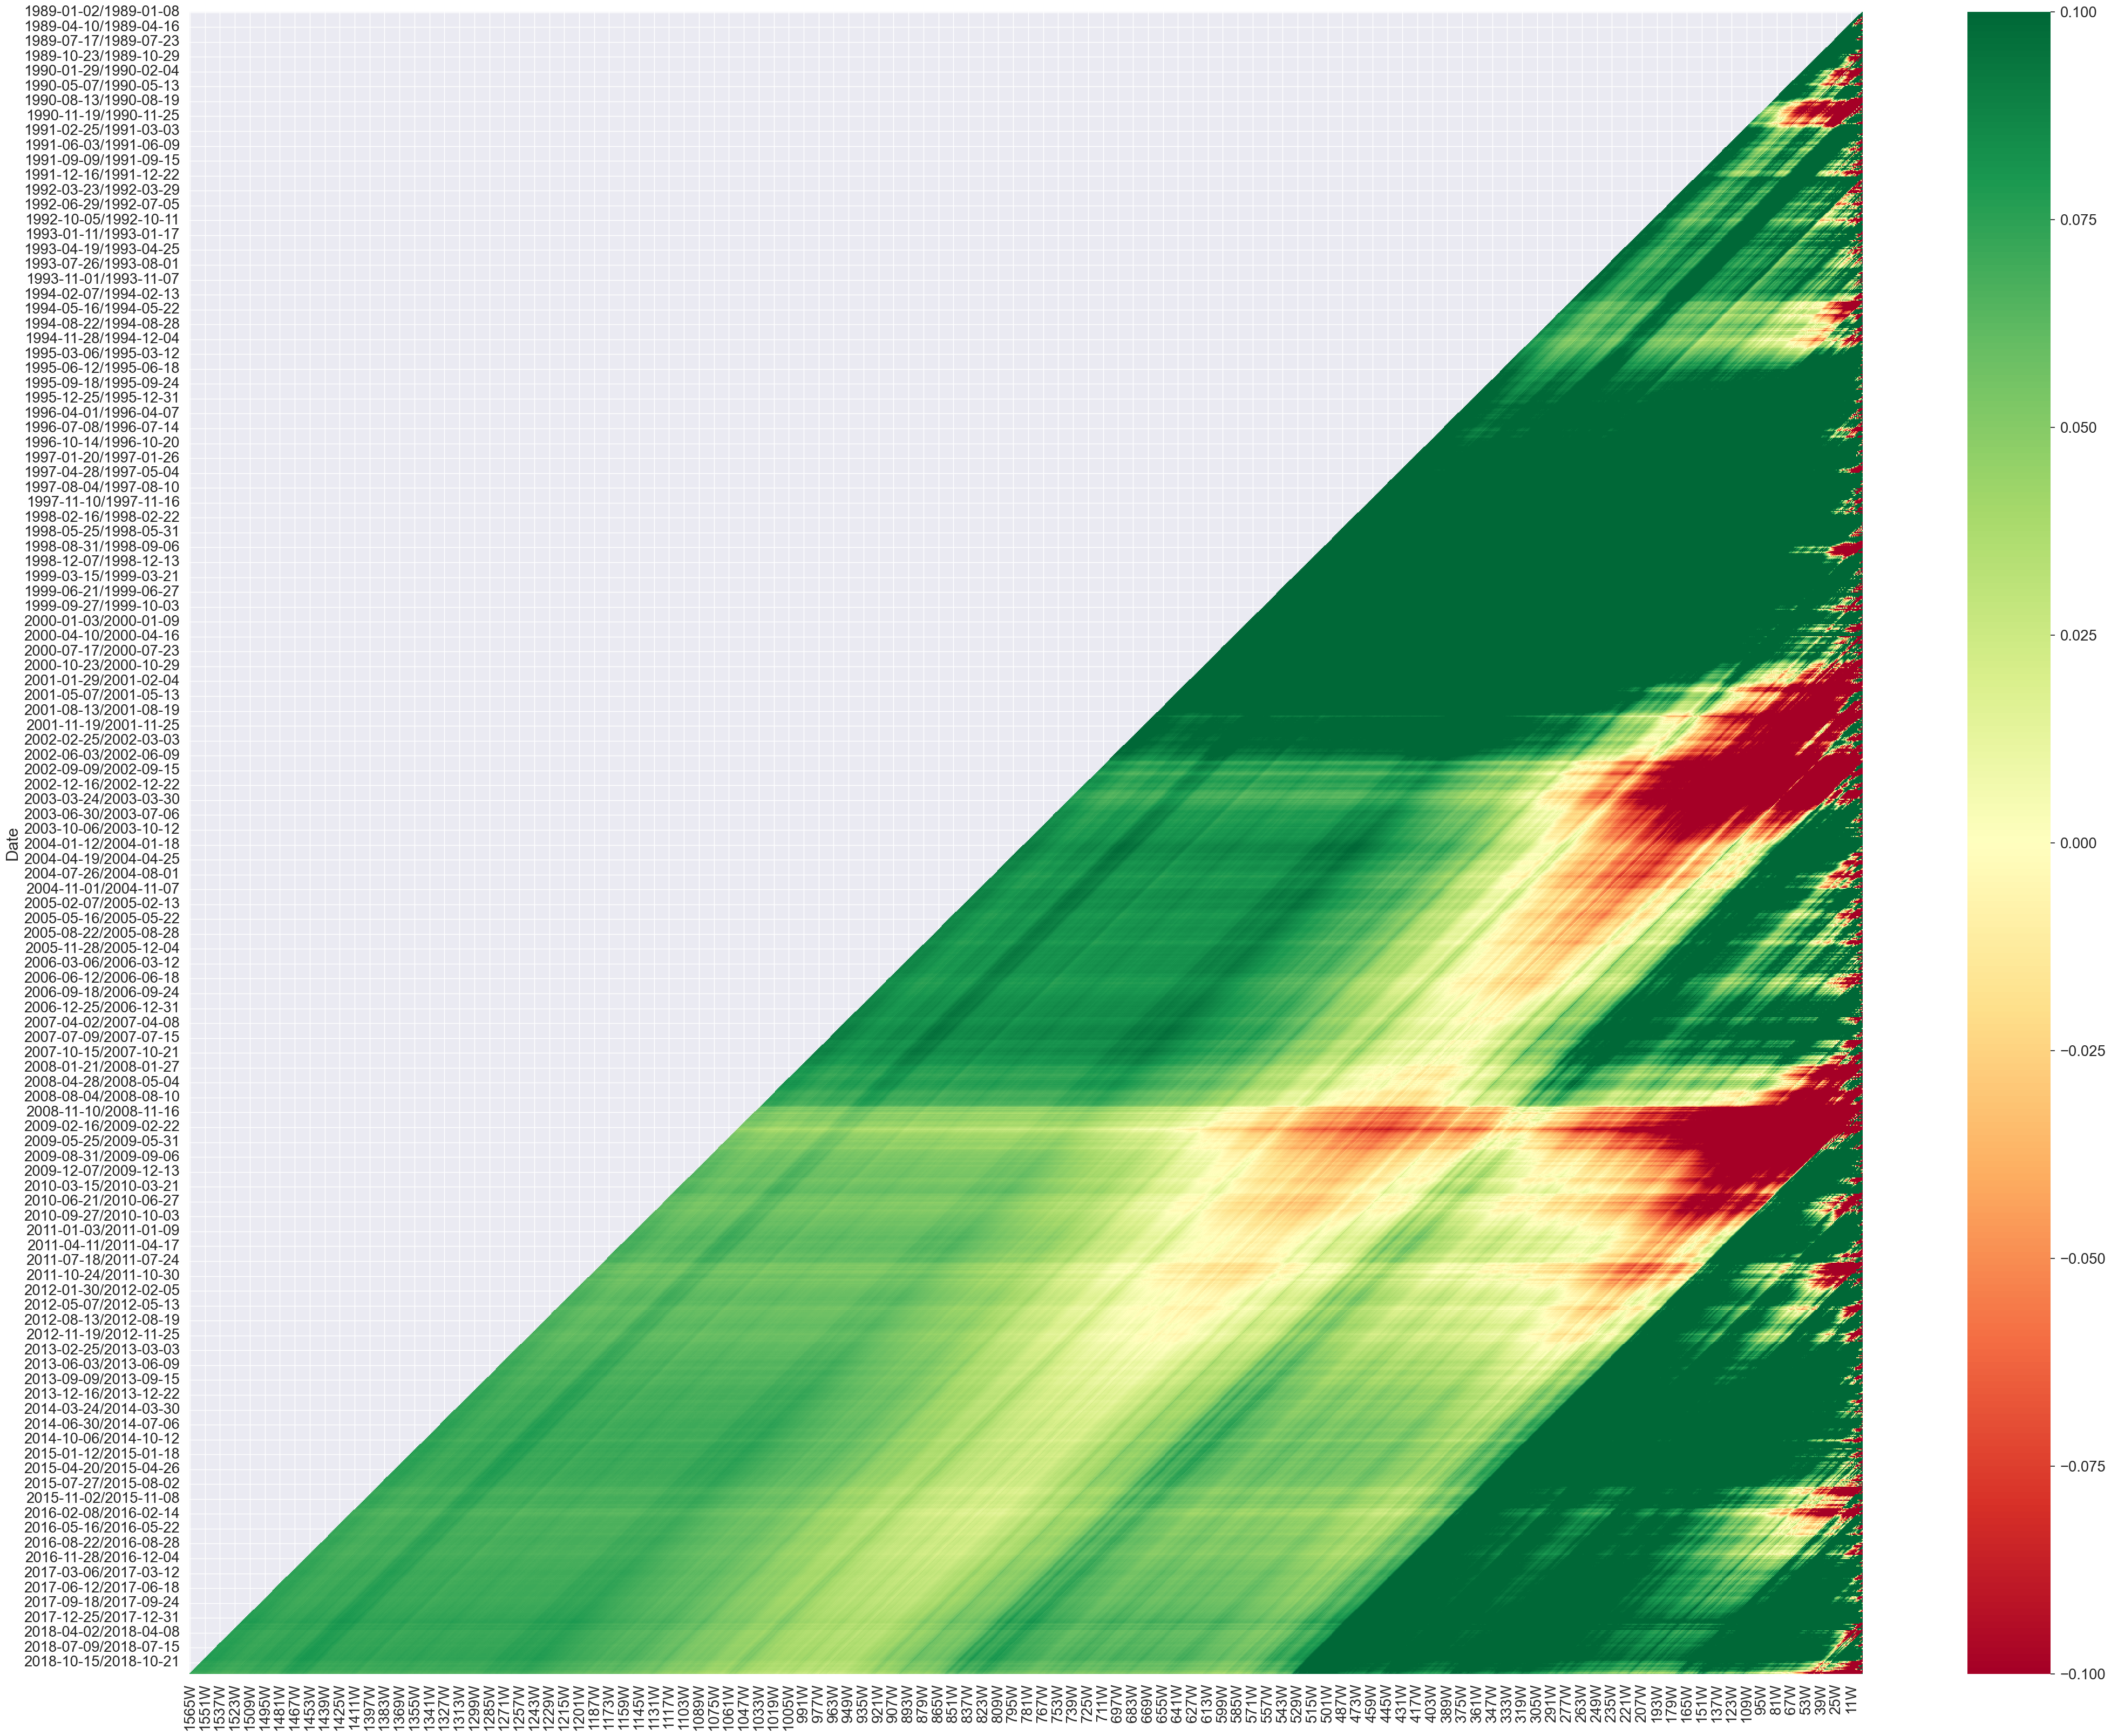

In [125]:
plt.figure(figsize=(50,40))
sns.set(font_scale=1.8)
sns.heatmap(triangle, annot =False, cmap = "RdYlGn", 
            vmin = -0.10, vmax = 0.10, center = 0)
#plt.tick_params(axis = "y", labelright =True)
plt.show()

## Exponentially-weighted Moving Averages (EWMA)


In [126]:
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

In [127]:
SP500 = pd.read_csv("SP500.csv", parse_dates= ["Date"], index_col= "Date", usecols= ["Date", "Close"])

In [128]:
SP500.head()

,Close
Date,
1970-12-31,92
1971-01-04,91
1971-01-05,92
1971-01-06,92
1971-01-07,92


In [129]:
SP500 = SP500.loc["2008-12-31":"2018-12-31"].copy()

In [130]:
SP500.Close.rolling(window = 10).mean()

Date
2008-12-31    NaN
2009-01-02    NaN
2009-01-05    NaN
2009-01-06    NaN
2009-01-07    NaN
             ... 
2018-12-21   2566
2018-12-24   2537
2018-12-26   2520
2018-12-27   2504
2018-12-28   2488
Name: Close, Length: 2516, dtype: float64

In [131]:
SP500.Close.ewm(span = 10, min_periods= 10).mean()

Date
2008-12-31    NaN
2009-01-02    NaN
2009-01-05    NaN
2009-01-06    NaN
2009-01-07    NaN
             ... 
2018-12-21   2547
2018-12-24   2511
2018-12-26   2504
2018-12-27   2501
2018-12-28   2498
Name: Close, Length: 2516, dtype: float64

In [132]:
SP500["SMA"] = SP500.Close.rolling(window = 100).mean()
SP500["EMA"] = SP500.Close.ewm(span = 100, min_periods= 100).mean()

In [133]:
SP500

,Close,SMA,EMA
Date,,,
2008-12-31,903,NaN,NaN
2009-01-02,932,NaN,NaN
2009-01-05,927,NaN,NaN
2009-01-06,935,NaN,NaN
2009-01-07,907,NaN,NaN
...,...,...,...
2018-12-21,2417,2786,2732
2018-12-24,2351,2781,2725
2018-12-26,2468,2778,2719


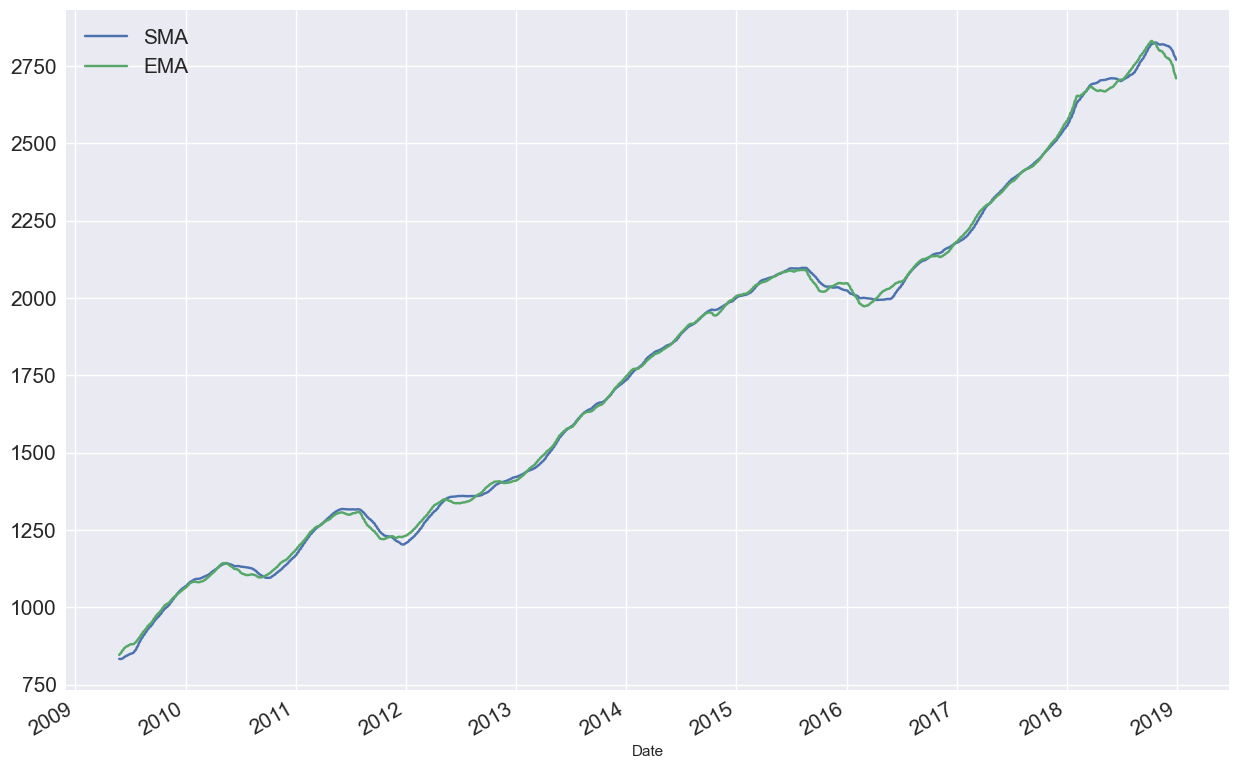

In [134]:
SP500.iloc[:,-2:].plot(figsize = (15,10), fontsize =15)
plt.legend(fontsize = 15)
plt.show()

### Expanding Windows

In [135]:
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

In [136]:
SP500 = pd.read_csv("SP500.csv", parse_dates= ["Date"], index_col= "Date", usecols= ["Date", "Close"])

In [137]:
SP500 = SP500.loc["2008-12-31":"2018-12-31"].copy()

In [138]:
SP500.head()

,Close
Date,
2008-12-31,903
2009-01-02,932
2009-01-05,927
2009-01-06,935
2009-01-07,907


In [139]:
SP500.Close.rolling(10).mean()

Date
2008-12-31    NaN
2009-01-02    NaN
2009-01-05    NaN
2009-01-06    NaN
2009-01-07    NaN
             ... 
2018-12-21   2566
2018-12-24   2537
2018-12-26   2520
2018-12-27   2504
2018-12-28   2488
Name: Close, Length: 2516, dtype: float64

In [140]:
SP500.Close.expanding(min_periods = 1).mean()

Date
2008-12-31    903
2009-01-02    918
2009-01-05    921
2009-01-06    924
2009-01-07    921
             ... 
2018-12-21   1764
2018-12-24   1764
2018-12-26   1765
2018-12-27   1765
2018-12-28   1765
Name: Close, Length: 2516, dtype: float64

In [141]:
SP500["SMA50"] = SP500.Close.rolling(50).mean()
SP500["EXP"] = SP500.Close.expanding().max()

In [142]:
SP500.head()

,Close,SMA50,EXP
Date,,,
2008-12-31,903,NaN,903
2009-01-02,932,NaN,932
2009-01-05,927,NaN,932
2009-01-06,935,NaN,935
2009-01-07,907,NaN,935


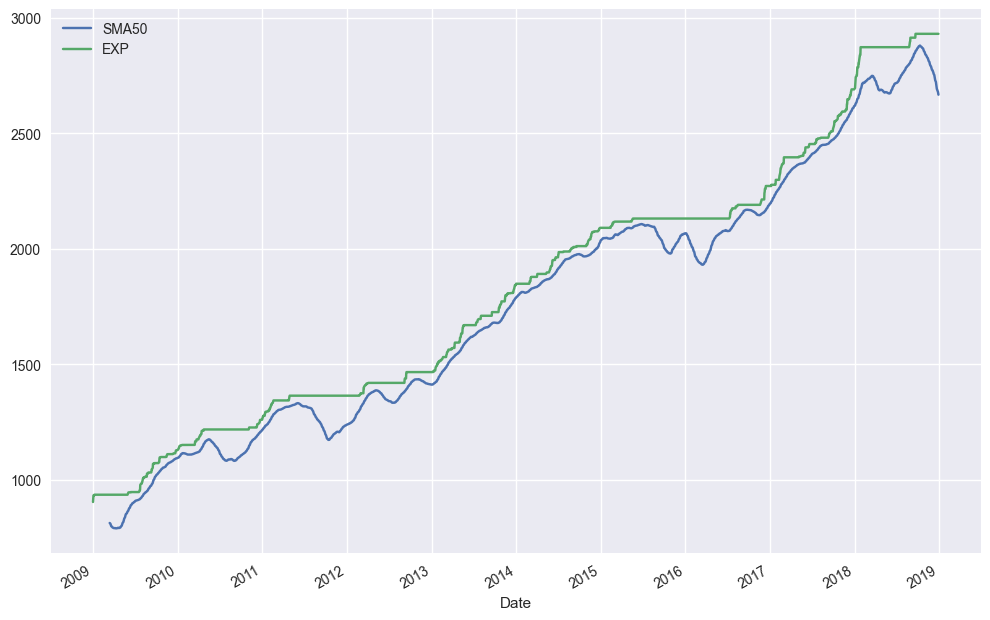

In [143]:
SP500.iloc[:, -2:].plot(figsize = (12, 8))
plt.show()

## Rolling Correlation

In [144]:
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")

In [145]:
stocks = pd.read_csv("stocks.csv", header = [0,1], index_col= [0], parse_dates= [0]).Close

In [146]:
stocks.head()

Ticker,AAPL,BA,DIS,IBM,KO,MSFT
Date,,,,,,
2010-01-04,6,44,27,73,18,23
2010-01-05,6,45,27,72,17,23
2010-01-06,6,47,27,72,17,23
2010-01-07,6,48,27,72,17,23
2010-01-08,6,48,27,72,17,23


In [147]:
app_ba = stocks.loc["2009-12-31":"2018", ["AAPL", "BA"]]

In [148]:
app_ba.head()

Ticker,AAPL,BA
Date,,
2010-01-04,6,44
2010-01-05,6,45
2010-01-06,6,47
2010-01-07,6,48
2010-01-08,6,48


In [149]:
month_ret = app_ba.resample("ME").last().pct_change().dropna()

In [150]:
month_ret.head()

Ticker,AAPL,BA
Date,,
2010-02-28,0,0
2010-03-31,0,0
2010-04-30,0,-0
2010-05-31,-0,-0
2010-06-30,-0,-0


In [151]:
month_ret.tail()

Ticker,AAPL,BA
Date,,
2018-08-31,0,-0
2018-09-30,-0,0
2018-10-31,-0,-0
2018-11-30,-0,-0
2018-12-31,-0,-0


In [152]:
month_ret.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 107 entries, 2010-02-28 to 2018-12-31
Freq: ME
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    107 non-null    float64
 1   BA      107 non-null    float64
dtypes: float64(2)
memory usage: 2.5 KB


In [153]:
month_ret.corr()

Ticker,AAPL,BA
Ticker,,
AAPL,1,0
BA,0,1


In [154]:
month_ret.AAPL.rolling(36).corr(month_ret.BA)

Date
2010-02-28   NaN
2010-03-31   NaN
2010-04-30   NaN
2010-05-31   NaN
2010-06-30   NaN
              ..
2018-08-31     0
2018-09-30     0
2018-10-31     0
2018-11-30     0
2018-12-31     0
Freq: ME, Length: 107, dtype: float64

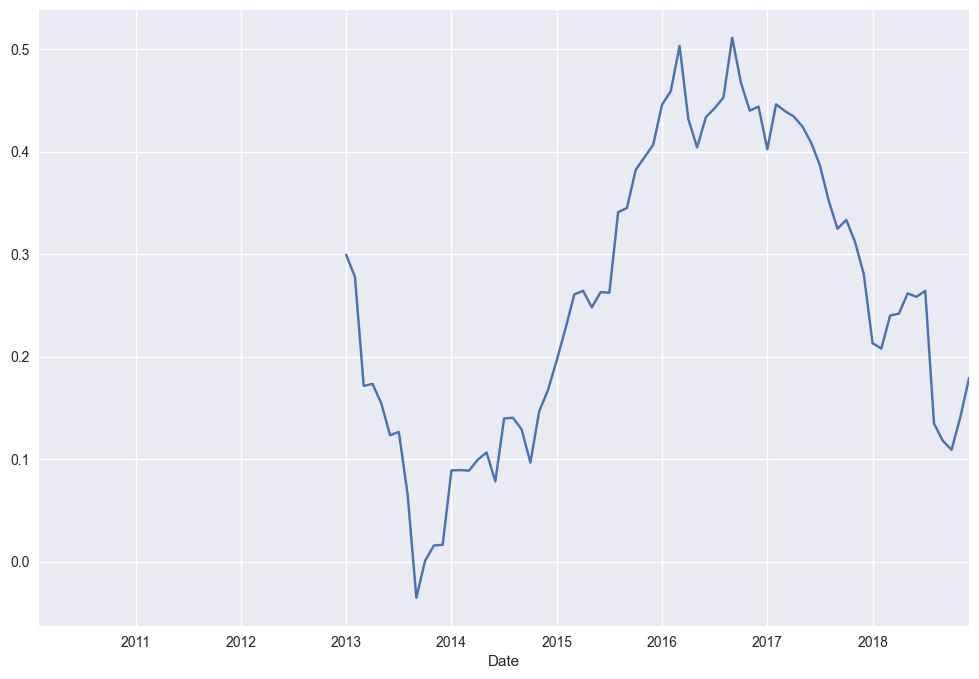

In [155]:
month_ret.AAPL.rolling(36).corr(month_ret.BA).plot(figsize = (12,8))
plt.show()

## rolling() with fixed-sized time offsets

In [156]:
app_ba.head(7)

Ticker,AAPL,BA
Date,,
2010-01-04,6,44
2010-01-05,6,45
2010-01-06,6,47
2010-01-07,6,48
2010-01-08,6,48
2010-01-11,6,47
2010-01-12,6,47


In [157]:
app_ba.BA.rolling(window = 3).mean().head(7)

Date
2010-01-04   NaN
2010-01-05   NaN
2010-01-06    45
2010-01-07    47
2010-01-08    48
2010-01-11    48
2010-01-12    48
Name: BA, dtype: float64

In [158]:
app_ba.head(7)

Ticker,AAPL,BA
Date,,
2010-01-04,6,44
2010-01-05,6,45
2010-01-06,6,47
2010-01-07,6,48
2010-01-08,6,48
2010-01-11,6,47
2010-01-12,6,47


In [159]:
app_ba.BA.rolling(window = "3D", min_periods = 3).mean()

Date
2010-01-04   NaN
2010-01-05   NaN
2010-01-06    45
2010-01-07    47
2010-01-08    48
              ..
2018-12-24   NaN
2018-12-26   NaN
2018-12-27   NaN
2018-12-28   307
2018-12-31   NaN
Name: BA, Length: 2264, dtype: float64

### Merging Time Series

In [160]:
import pandas as pd

In [161]:
stocks = pd.read_csv("stocks.csv", header = [0,1], index_col= [0], parse_dates= [0]).Close

In [162]:
stocks.head()

Ticker,AAPL,BA,DIS,IBM,KO,MSFT
Date,,,,,,
2010-01-04,6,44,27,73,18,23
2010-01-05,6,45,27,72,17,23
2010-01-06,6,47,27,72,17,23
2010-01-07,6,48,27,72,17,23
2010-01-08,6,48,27,72,17,23


In [163]:
aapl = stocks.loc["2010-01-01" : "2014-12-31", "AAPL"].to_frame()
aapl.head()

,AAPL
Date,
2010-01-04,6
2010-01-05,6
2010-01-06,6
2010-01-07,6
2010-01-08,6


In [164]:
ba = stocks.loc["2012-01-01" : "2016-12-31", "BA"].to_frame()
ba.head()

,BA
Date,
2012-01-03,61
2012-01-04,61
2012-01-05,60
2012-01-06,61
2012-01-09,61


In [165]:
aapl["BA"] = ba.BA

In [166]:
aapl.head()

,AAPL,BA
Date,,
2010-01-04,6,NaN
2010-01-05,6,NaN
2010-01-06,6,NaN
2010-01-07,6,NaN
2010-01-08,6,NaN


In [167]:
aapl.tail()

,AAPL,BA
Date,,
2014-12-24,25,115
2014-12-26,25,115
2014-12-29,25,116
2014-12-30,25,115
2014-12-31,24,114


In [168]:
aapl.dropna()

,AAPL,BA
Date,,
2012-01-03,12,61
2012-01-04,12,61
2012-01-05,13,60
2012-01-06,13,61
2012-01-09,13,61
...,...,...
2014-12-24,25,115
2014-12-26,25,115
2014-12-29,25,116


In [169]:
ba.reindex(aapl.index).dropna()

,BA
Date,
2012-01-03,61
2012-01-04,61
2012-01-05,60
2012-01-06,61
2012-01-09,61
...,...
2014-12-24,115
2014-12-26,115
2014-12-29,116


In [170]:
dis = stocks.loc["2010-01-01" : "2016-12-31", "DIS"].resample("W-Fri").last().to_frame()
dis.head()

,DIS
Date,
2010-01-08,27
2010-01-15,26
2010-01-22,26
2010-01-29,25
2010-02-05,25


In [171]:
aapl.head()

,AAPL,BA
Date,,
2010-01-04,6,NaN
2010-01-05,6,NaN
2010-01-06,6,NaN
2010-01-07,6,NaN
2010-01-08,6,NaN


In [172]:
aapl["DIS"] = dis.DIS

In [173]:
aapl.head(10)

,AAPL,BA,DIS
Date,,,
2010-01-04,6,NaN,NaN
2010-01-05,6,NaN,NaN
2010-01-06,6,NaN,NaN
2010-01-07,6,NaN,NaN
2010-01-08,6,NaN,27
2010-01-11,6,NaN,NaN
2010-01-12,6,NaN,NaN
2010-01-13,6,NaN,NaN
2010-01-14,6,NaN,NaN


In [174]:
dis.reindex(aapl.index)

,DIS
Date,
2010-01-04,NaN
2010-01-05,NaN
2010-01-06,NaN
2010-01-07,NaN
2010-01-08,27
...,...
2014-12-24,NaN
2014-12-26,87
2014-12-29,NaN


In [175]:
dis["AAPL"] = aapl.AAPL

In [176]:
dis.head(10)

,DIS,AAPL
Date,,
2010-01-08,27,6
2010-01-15,26,6
2010-01-22,26,6
2010-01-29,25,6
2010-02-05,25,6
2010-02-12,26,6
2010-02-19,27,6
2010-02-26,27,6
2010-03-05,28,7
